<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Aerofoil_CFD_with_K3D_and_Adjacency_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
# Install necessary libraries
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!uv pip install -q -U "numpy>=2.3.5,<2.4" "scipy>=1.16,<1.17" mpi4py pyfr k3d cupy-cuda12x trimesh matplotlib rtree embreex ipywidgets

from google.colab import output
output.enable_custom_widget_manager()

Active Colab runtime
  NumPy:      2.0.2
  SciPy:      1.16.3
  CuPy:       14.1.1
  Trimesh:    5.0.0
  K3D:        2.18.1
  CUDA GPUs:  1
Colab widget manager enabled.
3D D3Q19 setup | nodes=393,216 | tau=0.53200 | nu=0.010667 | ray backend=Embree
Wing angle setup | target AoA=6.00 deg | pitch envelope=[4.00, 8.00] deg | NY=48 | projected half-height=5.99 cells
Snapshot schedule | 2D=[240, 780, 1320, 1860, 2400] | K3D=[0, 2400] | GPU captures=[0, 240, 780, 1320, 1860, 2400]
snapshot 01/06 | step=   0 | t*=0.000 | AoA=6.00 deg | mean rho=1.000000
completed step 200/2400
snapshot 02/06 | step= 240 | t*=0.300 | AoA=7.90 deg | mean rho=1.009166
completed step 400/2400
completed step 600/2400
snapshot 03/06 | step= 780 | t*=0.975 | AoA=4.38 deg | mean rho=1.001053
completed step 800/2400
completed step 1000/2400
completed step 1200/2400
snapshot 04/06 | step=1320 | t*=1.650 | AoA=7.18 deg | mean rho=1.000911
completed step 1400/2400
completed step 1600/2400
completed step 1800/2400
snapsh

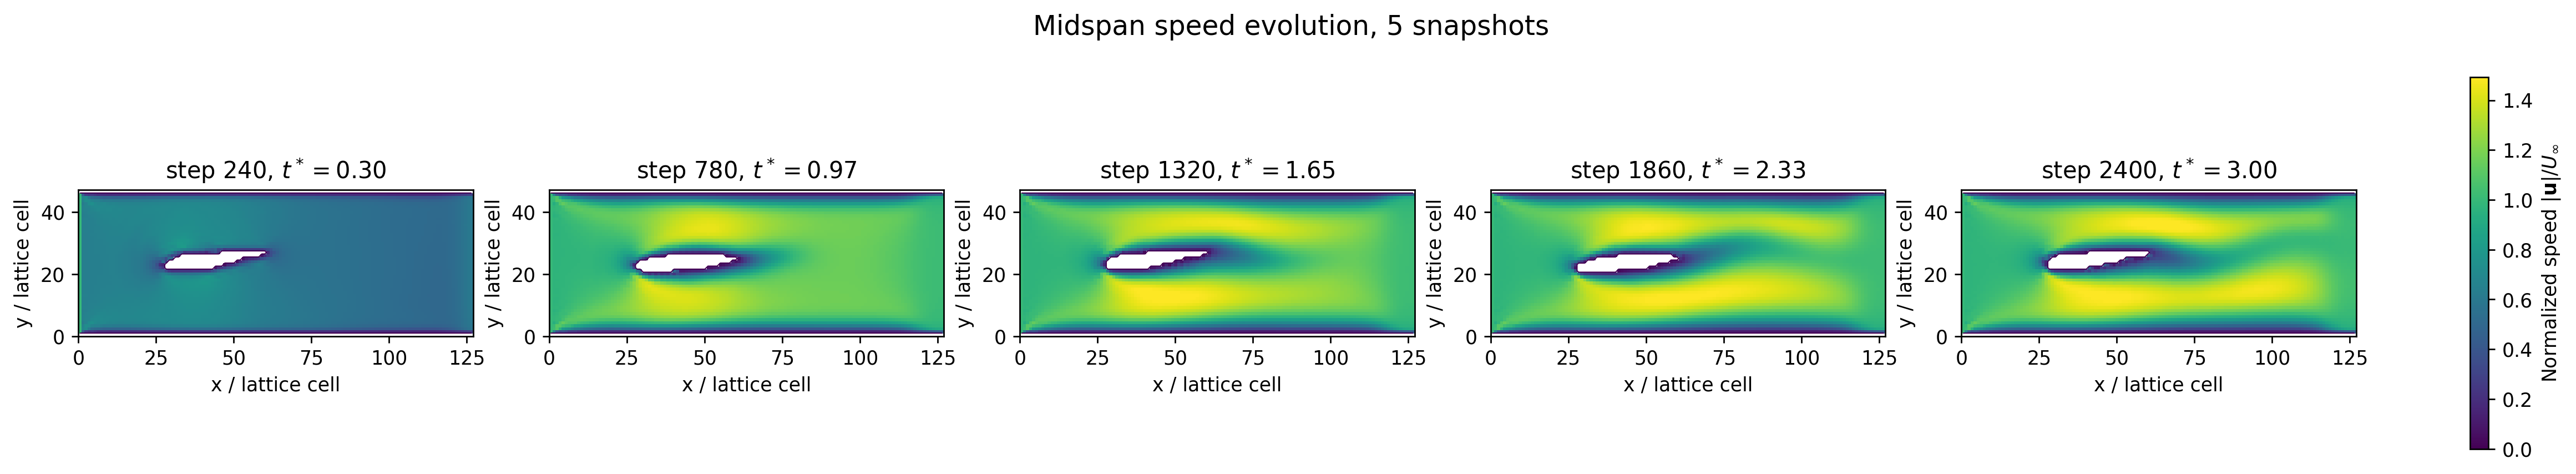

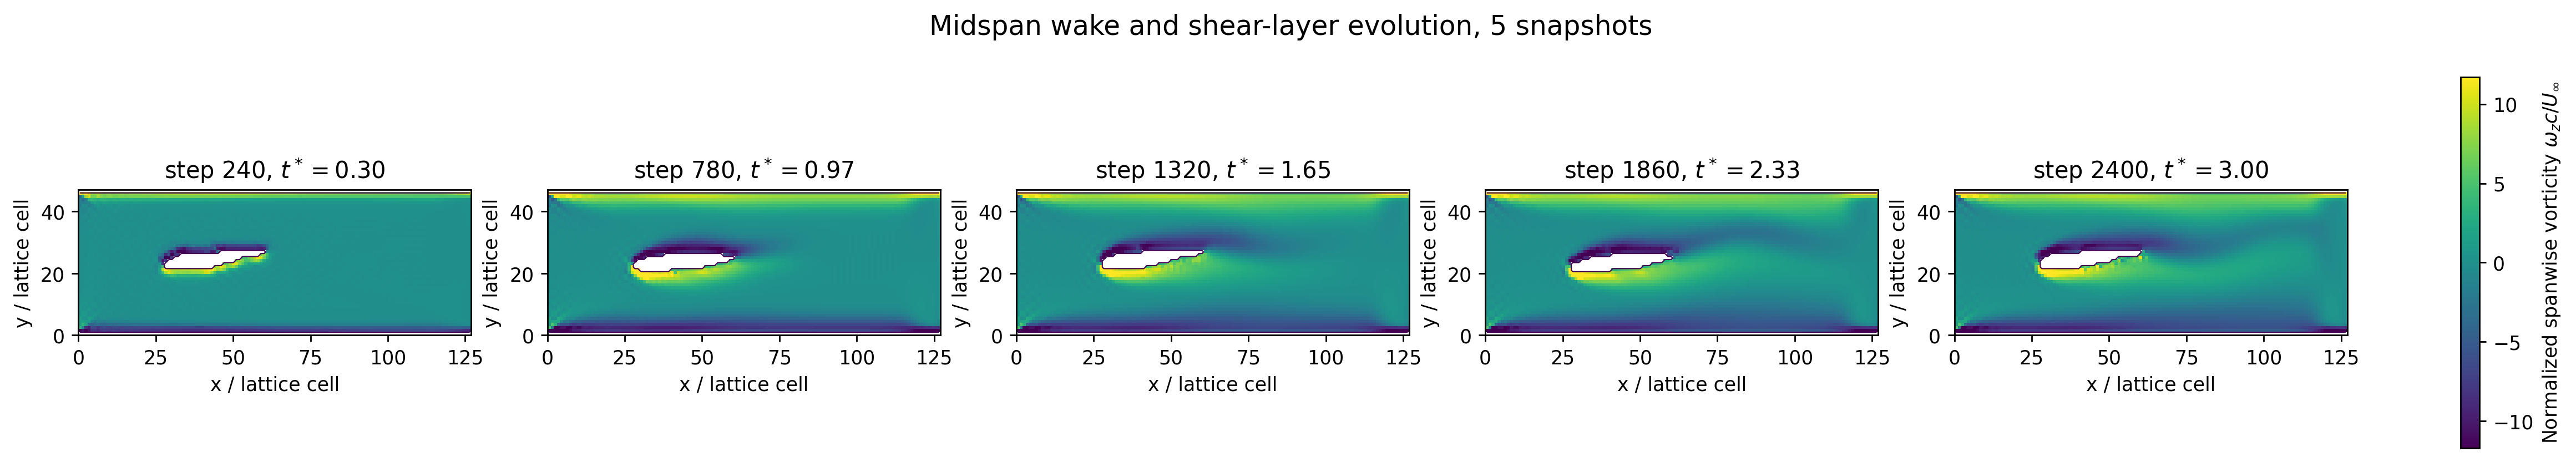


Rendering 2 requested K3D snapshots.
3D snapshot 01/02 | step=   0 | t*=0.000 | AoA=6.00 deg
K3D static payload | step=0 | wing vertices=716 | velocity segments=672 | streamlines=0
K3D standalone HTML saved to: /content/wind_tunnel_3d_output/k3d_snapshot_01_step_0000.html
3D snapshot 02/02 | step=2400 | t*=3.000 | AoA=6.00 deg
K3D static payload | step=2400 | wing vertices=716 | velocity segments=672 | streamlines=35
K3D standalone HTML saved to: /content/wind_tunnel_3d_output/k3d_snapshot_02_step_2400.html
K3D gallery HTML saved to: /content/wind_tunnel_3d_output/k3d_results_gallery.html
K3D result server | port=49539 | proxy=https://49539-gpu-l4-s-kkb-usw4a0-1h89ho2br5xna-a.us-west4-0.prod.colab.dev
K3D separate-tab auto-open failed: NameError("name 'json' is not defined")


K3D separate-tab URL: https://49539-gpu-l4-s-kkb-usw4a0-1h89ho2br5xna-a.us-west4-0.prod.colab.dev/k3d_results_gallery.html
Rendering inline K3D fallback because the browser did not confirm a separate tab.
K3D standalone HTML saved to: /content/wind_tunnel_3d_output/k3d_inline_fallback_01.html


K3D standalone HTML saved to: /content/wind_tunnel_3d_output/k3d_inline_fallback_02.html



Simulation summary
  Grid: 128 x 48 x 64
  Wing target AoA: 6.000 deg
  Wing pitch envelope: 4.000 to 8.000 deg
  Angle-derived streamline half-width: 13.440 cells
  D3Q19 relaxation time: 0.532000
  Lattice viscosity: 0.010667
  B-rep query backend: Embree
  GPU captures: 6
  2D snapshots shown: 5
  K3D snapshots shown: 2
  K3D separate-tab mode: enabled
  2D steps: [240, 780, 1320, 1860, 2400]
  K3D steps: [0, 2400]
  Output directory: /content/wind_tunnel_3d_output


In [ ]:
"""Run an adjacency-based D3Q19 wind tunnel around a 3D wing B-rep.

CuPy advances the lattice Boltzmann populations on an NVIDIA L4 GPU. Trimesh
constructs and voxelizes a watertight finite NACA 0012 wing. K3D renders a separately
configurable set of interactive 3D snapshots.

WING_ANGLE_OF_ATTACK_DEG is the master geometric angle control. The wing B-rep,
pitch motion envelope, tunnel cross-stream clearance, streamline seed coverage,
and reported angle all derive from this value. Reynolds number and inlet speed
stay fixed unless changed explicitly, which preserves a controlled comparison
between different angles of attack.

The default output is five 2D snapshots and two K3D snapshots. The K3D schedule
includes the true initial state at step 0 and the final state at TOTAL_STEPS.
K3D is forced through a live widget path and a standalone HTML snapshot path.
"""

from dataclasses import dataclass
from functools import partial
from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer
import math
from pathlib import Path
import socket
import threading
from urllib.parse import quote
from typing import Any, Sequence

import cupy as cp
import k3d
import matplotlib.pyplot as plt
import numpy as np
import trimesh
from IPython.display import HTML, display


def print_runtime_versions() -> None:
    """Print the active scientific and GPU package versions."""
    import scipy

    print("Active Colab runtime")
    print(f"  NumPy:      {np.__version__}")
    print(f"  SciPy:      {scipy.__version__}")
    print(f"  CuPy:       {cp.__version__}")
    print(f"  Trimesh:    {trimesh.__version__}")
    print(f"  K3D:        {k3d.__version__}")
    print(f"  CUDA GPUs:  {cp.cuda.runtime.getDeviceCount()}")


def initialize_colab_widget_support() -> None:
    """Enable Colab widget support when available."""
    try:
        from google.colab import output

        output.enable_custom_widget_manager()
        print("Colab widget manager enabled.")
    except Exception as error:
        print(f"Colab widget manager setup skipped: {error!r}")



# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------

# Cartesian wind-tunnel lattice.
# NX and NZ stay fixed. NY can expand automatically to preserve cross-stream
# clearance as the wing angle increases.
NX = 128
BASE_NY = 48
NZ = 64

# D3Q19 fluid controls in lattice units.
TOTAL_STEPS = 2400

# Snapshot controls.
SNAPSHOT_COUNT_2D = 5
SNAPSHOT_COUNT_3D = 2
SNAPSHOT_START_STEP_2D = 240
SNAPSHOT_START_STEP_3D = 0

INLET_SPEED = 0.040
REYNOLDS_NUMBER = 120.0
DENSITY_REFERENCE = 1.0
DENSITY_FLOOR = 1.0e-7
INLET_RAMP_STEPS = 240
SPONGE_LENGTH_CELLS = 14
SPONGE_MAX_RELAXATION = 0.045
WALL_THICKNESS_CELLS = 1

# NACA 0012 finite-wing triangular B-rep.
NACA_THICKNESS_RATIO = 0.12
WING_CHORD_CELLS = 32.0
WING_SPAN_CELLS = 34.0
WING_TAPER_RATIO = 0.82
WING_LEADING_EDGE_X = 28.0
WING_PROFILE_POINTS = 52
WING_SPAN_STATIONS = 7

# ---------------------------------------------------
# MASTER WING ANGLE CONTROL
# ---------------------------------------------------
# Positive values rotate the leading-to-trailing chord counterclockwise in
# the x-y plane. This is the mean angle if pitch motion is enabled.
WING_ANGLE_OF_ATTACK_DEG = 6.0

# Prescribed rigid-body motion.
# Set ENABLE_WING_MOTION = False to hold the wing at exactly
# WING_ANGLE_OF_ATTACK_DEG for the complete simulation.
ENABLE_WING_MOTION = True
PITCH_AMPLITUDE_DEG = 2.0
HEAVE_AMPLITUDE_CELLS = 0.75
HEAVE_PHASE_DEG = 90.0
MOTION_PERIOD_STEPS = 1200
GEOMETRY_UPDATE_INTERVAL = 30

# Automatic angle-dependent geometry controls.
AUTO_EXPAND_TUNNEL_FOR_WING_ANGLE = True
MIN_WING_WALL_CLEARANCE_CELLS = 3.0
STREAMLINE_ENVELOPE_GAIN = 1.20

# Geometry classification and visualization.
B_REP_QUERY_CHUNK_SIZE = 250_000
SURFACE_VOXEL_PITCH = 0.75
K3D_VECTOR_STRIDE = (10, 6, 8)
K3D_VECTOR_GAIN = 26.0
K3D_LINE_WIDTH = 0.18
K3D_STREAMLINE_SEEDS_Y = 5
K3D_STREAMLINE_SEEDS_Z = 7
K3D_STREAMLINE_STEP = 0.75
K3D_STREAMLINE_STEPS = 180
K3D_ANIMATION_FPS = 2.0
K3D_IFRAME_HEIGHT = 720
K3D_BACKGROUND_COLOR = 0x1E1E1E
K3D_GRID_COLOR = 0x5B6470
K3D_LABEL_COLOR = 0xF0F0F0
K3D_TUNNEL_COLOR = 0x788391
K3D_WING_COLOR = 0xC7D2E3
K3D_REFERENCE_WING_COLOR = 0x607D9B
K3D_SHOW_STATIC_SEQUENCE = True
K3D_STATIC_SEQUENCE_HEIGHT = 560
K3D_SHOW_LIVE_WIDGET = False
K3D_SHOW_STANDALONE_HTML = True
K3D_EMBED_MODE = "srcdoc"

# K3D browser-tab controls.
# Colab browser security can block programmatic popups. The code therefore
# attempts one automatic tab, then always prints a clickable authenticated
# Colab-proxy link as a fallback.
K3D_OPEN_RESULTS_IN_NEW_TAB = True
K3D_NEW_TAB_AUTO_OPEN = True
K3D_NEW_TAB_KEEP_INLINE_FALLBACK = False
K3D_NEW_TAB_GALLERY_FILENAME = "k3d_results_gallery.html"
K3D_NEW_TAB_SERVER_BIND = "127.0.0.1"

# Output controls.
PLOT_DPI = 250
PROGRESS_INTERVAL = 200
EXPORT_DIRECTORY = Path("wind_tunnel_3d_output")
EXPORT_WING_STL = True

# ---------------------------------------------------
# DERIVED ANGLE-DEPENDENT GEOMETRY
# ---------------------------------------------------
# The maximum chord arm from the quarter-chord pivot is 0.75 c.
# The NACA thickness ratio is the full maximum thickness, so its half
# thickness is 0.5 * t/c * c.
_ACTIVE_PITCH_AMPLITUDE_DEG = (
    abs(PITCH_AMPLITUDE_DEG)
    if ENABLE_WING_MOTION
    else 0.0
)
_ANGLE_MIN_DEG = WING_ANGLE_OF_ATTACK_DEG - _ACTIVE_PITCH_AMPLITUDE_DEG
_ANGLE_MAX_DEG = WING_ANGLE_OF_ATTACK_DEG + _ACTIVE_PITCH_AMPLITUDE_DEG
_ANGLE_ENVELOPE_DEG = np.linspace(
    _ANGLE_MIN_DEG,
    _ANGLE_MAX_DEG,
    721,
    dtype=np.float64,
)
_ANGLE_ENVELOPE_RAD = np.deg2rad(_ANGLE_ENVELOPE_DEG)

_MAX_CHORD_ARM_CELLS = 0.75 * WING_CHORD_CELLS
_MAX_HALF_THICKNESS_CELLS = (
    0.5 * NACA_THICKNESS_RATIO * WING_CHORD_CELLS
)

_WING_ROTATED_HALF_HEIGHT_CELLS = float(
    np.max(
        _MAX_CHORD_ARM_CELLS * np.abs(np.sin(_ANGLE_ENVELOPE_RAD))
        + _MAX_HALF_THICKNESS_CELLS * np.abs(np.cos(_ANGLE_ENVELOPE_RAD))
    )
)
_WING_HEAVE_ENVELOPE_CELLS = (
    abs(HEAVE_AMPLITUDE_CELLS)
    if ENABLE_WING_MOTION
    else 0.0
)
_WING_TOTAL_HALF_HEIGHT_CELLS = (
    _WING_ROTATED_HALF_HEIGHT_CELLS
    + _WING_HEAVE_ENVELOPE_CELLS
)

_REQUIRED_NY = int(
    math.ceil(
        2.0
        * (
            _WING_TOTAL_HALF_HEIGHT_CELLS
            + MIN_WING_WALL_CLEARANCE_CELLS
            + WALL_THICKNESS_CELLS
        )
        + 1.0
    )
)
NY = (
    max(BASE_NY, _REQUIRED_NY)
    if AUTO_EXPAND_TUNNEL_FOR_WING_ANGLE
    else BASE_NY
)

WING_CENTER_Y = 0.5 * (NY - 1)
WING_CENTER_Z = NZ / 2.0

K3D_STREAMLINE_SEED_HALF_WIDTH_CELLS = min(
    0.46 * (NY - 1 - 2 * WALL_THICKNESS_CELLS),
    max(
        0.42 * WING_CHORD_CELLS,
        STREAMLINE_ENVELOPE_GAIN * _WING_TOTAL_HALF_HEIGHT_CELLS,
    ),
)

plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
plt.rcParams["font.weight"] = "normal"

K3D_VIRIDIS = [
    [
        float(position),
        float(red),
        float(green),
        float(blue),
    ]
    for position, (red, green, blue, _) in zip(
        np.linspace(0.0, 1.0, 256),
        plt.get_cmap("viridis")(np.linspace(0.0, 1.0, 256)),
    )
]

# Persistent Colab-local HTTP server state for K3D result tabs.
_K3D_HTTP_SERVER: ThreadingHTTPServer | None = None
_K3D_HTTP_THREAD: threading.Thread | None = None
_K3D_HTTP_PORT: int | None = None
_K3D_PROXY_BASE_URL: str | None = None


# ---------------------------------------------------
# D3Q19 LATTICE CONSTANTS
# ---------------------------------------------------

D3Q19_VELOCITIES = np.asarray(
    [
        [0, 0, 0],
        [1, 0, 0],
        [-1, 0, 0],
        [0, 1, 0],
        [0, -1, 0],
        [0, 0, 1],
        [0, 0, -1],
        [1, 1, 0],
        [-1, -1, 0],
        [1, -1, 0],
        [-1, 1, 0],
        [1, 0, 1],
        [-1, 0, -1],
        [1, 0, -1],
        [-1, 0, 1],
        [0, 1, 1],
        [0, -1, -1],
        [0, 1, -1],
        [0, -1, 1],
    ],
    dtype=np.int32,
)
D3Q19_WEIGHTS = np.asarray(
    [1.0 / 3.0]
    + [1.0 / 18.0] * 6
    + [1.0 / 36.0] * 12,
    dtype=np.float32,
)
D3Q19_OPPOSITE = np.asarray(
    [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15, 18, 17],
    dtype=np.int32,
)
Q = D3Q19_VELOCITIES.shape[0]


@dataclass(frozen=True)
class MotionState:
    """Describe the instantaneous rigid-body state of the wing."""

    pitch_rad: float
    angular_velocity_rad_per_step: float
    heave_cells: float
    heave_velocity_cells_per_step: float


@dataclass
class FlowSnapshot:
    """Hold compact host-side data for one simulation time."""

    step: int
    convective_time: float
    pitch_deg: float
    heave_cells: float
    mean_density: float
    speed_slice: np.ndarray
    vorticity_slice: np.ndarray
    solid_slice: np.ndarray
    sampled_vectors: np.ndarray
    sampled_speeds: np.ndarray
    wing_vertices: np.ndarray


@dataclass
class SimulationResult:
    """Collect simulation geometry, snapshots, and the final flow field."""

    snapshots: list[FlowSnapshot]
    snapshot_steps_2d: np.ndarray
    snapshot_steps_3d: np.ndarray
    vector_origins: np.ndarray
    wing_faces: np.ndarray
    tunnel_vertices: np.ndarray
    tunnel_faces: np.ndarray
    final_velocity: np.ndarray
    final_solid: np.ndarray
    final_wing_mesh: trimesh.Trimesh
    ray_backend: str
    relaxation_time: float
    lattice_viscosity: float


def configure_k3d_snapshot_protocol() -> None:
    """Select K3D's Colab-compatible text serialization protocol."""
    switch_protocol = getattr(k3d, "switch_to_text_protocol", None)
    if callable(switch_protocol):
        switch_protocol()


def validate_controls() -> None:
    """Raise informative errors for unstable or inconsistent controls."""
    if min(NX, NY, NZ) < 12:
        raise ValueError("Each lattice dimension must contain at least 12 cells.")
    if not 0.0 < INLET_SPEED < 0.12:
        raise ValueError("INLET_SPEED should stay below 0.12 in lattice units.")
    if REYNOLDS_NUMBER <= 0.0:
        raise ValueError("REYNOLDS_NUMBER must be positive.")
    if TOTAL_STEPS < 1:
        raise ValueError("TOTAL_STEPS must be at least 1.")
    if SNAPSHOT_COUNT_2D < 1:
        raise ValueError("SNAPSHOT_COUNT_2D must be at least 1.")
    if SNAPSHOT_COUNT_3D < 1:
        raise ValueError("SNAPSHOT_COUNT_3D must be at least 1.")
    if not 0 <= SNAPSHOT_START_STEP_2D <= TOTAL_STEPS:
        raise ValueError(
            "SNAPSHOT_START_STEP_2D must lie between 0 and TOTAL_STEPS."
        )
    if not 0 <= SNAPSHOT_START_STEP_3D <= TOTAL_STEPS:
        raise ValueError(
            "SNAPSHOT_START_STEP_3D must lie between 0 and TOTAL_STEPS."
        )
    if SNAPSHOT_COUNT_2D > TOTAL_STEPS - SNAPSHOT_START_STEP_2D + 1:
        raise ValueError(
            "SNAPSHOT_COUNT_2D exceeds the number of available time steps."
        )
    if SNAPSHOT_COUNT_3D > TOTAL_STEPS - SNAPSHOT_START_STEP_3D + 1:
        raise ValueError(
            "SNAPSHOT_COUNT_3D exceeds the number of available time steps."
        )
    if GEOMETRY_UPDATE_INTERVAL < 1:
        raise ValueError("GEOMETRY_UPDATE_INTERVAL must be positive.")
    if not np.isfinite(WING_ANGLE_OF_ATTACK_DEG):
        raise ValueError("WING_ANGLE_OF_ATTACK_DEG must be finite.")
    if not np.isfinite(PITCH_AMPLITUDE_DEG):
        raise ValueError("PITCH_AMPLITUDE_DEG must be finite.")
    if MIN_WING_WALL_CLEARANCE_CELLS < 1.0:
        raise ValueError(
            "MIN_WING_WALL_CLEARANCE_CELLS should be at least 1 lattice cell."
        )

    available_half_height = (
        0.5 * (NY - 1)
        - WALL_THICKNESS_CELLS
        - MIN_WING_WALL_CLEARANCE_CELLS
    )
    if _WING_TOTAL_HALF_HEIGHT_CELLS > available_half_height:
        raise ValueError(
            "The selected wing angle and motion envelope do not fit inside "
            "the current NY dimension. Enable "
            "AUTO_EXPAND_TUNNEL_FOR_WING_ANGLE or increase BASE_NY."
        )


def create_snapshot_schedule(
    start_step: int,
    end_step: int,
    count: int,
) -> np.ndarray:
    """Return an integer snapshot schedule that includes both endpoints.

    Args:
        start_step: First simulation step to include.
        end_step: Final simulation step to include.
        count: Number of requested snapshots.

    Returns:
        A strictly increasing integer array of simulation steps.
    """
    if count == 1:
        return np.asarray([end_step], dtype=np.int32)

    schedule = np.rint(
        np.linspace(
            start_step,
            end_step,
            count,
            dtype=np.float64,
        )
    ).astype(np.int32)

    schedule[0] = np.int32(start_step)
    schedule[-1] = np.int32(end_step)

    if np.unique(schedule).size != count:
        raise ValueError(
            "The requested snapshot count is too dense for the selected "
            "step interval."
        )

    return schedule


def select_snapshots(
    result: SimulationResult,
    requested_steps: np.ndarray,
) -> list[FlowSnapshot]:
    """Return captured snapshots matching an explicit step schedule."""
    snapshots_by_step = {
        int(snapshot.step): snapshot
        for snapshot in result.snapshots
    }

    selected: list[FlowSnapshot] = []
    for step in requested_steps:
        step_int = int(step)
        if step_int not in snapshots_by_step:
            raise RuntimeError(
                f"Snapshot for simulation step {step_int} was not captured."
            )
        selected.append(snapshots_by_step[step_int])

    return selected


def naca_symmetric_profile(
    thickness_ratio: float,
    point_count: int,
) -> np.ndarray:
    """Return a closed NACA 00xx perimeter in normalized chord coordinates.

    Args:
        thickness_ratio: Maximum thickness divided by chord.
        point_count: Number of cosine-spaced points on each half surface.

    Returns:
        An ``(m, 2)`` array ordered around the airfoil perimeter.
    """
    if point_count < 12:
        raise ValueError("point_count must be at least 12.")

    beta = np.linspace(0.0, np.pi, point_count, dtype=np.float64)
    x_coord = 0.5 * (1.0 - np.cos(beta))
    thickness = 5.0 * thickness_ratio * (
        0.2969 * np.sqrt(np.maximum(x_coord, 0.0))
        - 0.1260 * x_coord
        - 0.3516 * x_coord**2
        + 0.2843 * x_coord**3
        - 0.1036 * x_coord**4
    )

    upper = np.column_stack((x_coord[::-1], thickness[::-1]))
    lower = np.column_stack((x_coord[1:-1], -thickness[1:-1]))
    return np.vstack((upper, lower)).astype(np.float64)


def create_wing_brep() -> tuple[trimesh.Trimesh, np.ndarray]:
    """Create a capped, tapered NACA 0012 finite-wing triangular B-rep.

    Returns:
        A watertight Trimesh object and its quarter-chord rotation pivot.
    """
    profile = naca_symmetric_profile(
        NACA_THICKNESS_RATIO,
        WING_PROFILE_POINTS,
    )
    ring_size = profile.shape[0]
    span_positions = np.linspace(
        WING_CENTER_Z - 0.5 * WING_SPAN_CELLS,
        WING_CENTER_Z + 0.5 * WING_SPAN_CELLS,
        WING_SPAN_STATIONS,
        dtype=np.float64,
    )

    vertices: list[list[float]] = []
    for z_coord in span_positions:
        span_fraction = abs(
            2.0 * (z_coord - WING_CENTER_Z) / WING_SPAN_CELLS
        )
        chord = WING_CHORD_CELLS * (
            1.0 - (1.0 - WING_TAPER_RATIO) * span_fraction
        )
        quarter_chord_x = WING_LEADING_EDGE_X + 0.25 * WING_CHORD_CELLS
        local_leading_edge_x = quarter_chord_x - 0.25 * chord

        for x_normalized, y_normalized in profile:
            vertices.append(
                [
                    local_leading_edge_x + chord * x_normalized,
                    WING_CENTER_Y + chord * y_normalized,
                    z_coord,
                ]
            )

    faces: list[list[int]] = []
    for station in range(WING_SPAN_STATIONS - 1):
        ring_a = station * ring_size
        ring_b = (station + 1) * ring_size
        for profile_index in range(ring_size):
            next_index = (profile_index + 1) % ring_size
            a = ring_a + profile_index
            b = ring_a + next_index
            c = ring_b + profile_index
            d = ring_b + next_index
            faces.append([a, c, d])
            faces.append([a, d, b])

    start_cap_center = len(vertices)
    start_ring = np.asarray(vertices[:ring_size], dtype=np.float64)
    vertices.append(start_ring.mean(axis=0).tolist())

    end_cap_center = len(vertices)
    end_ring_start = (WING_SPAN_STATIONS - 1) * ring_size
    end_ring = np.asarray(
        vertices[end_ring_start : end_ring_start + ring_size],
        dtype=np.float64,
    )
    vertices.append(end_ring.mean(axis=0).tolist())

    for profile_index in range(ring_size):
        next_index = (profile_index + 1) % ring_size
        faces.append([start_cap_center, next_index, profile_index])
        faces.append(
            [
                end_cap_center,
                end_ring_start + profile_index,
                end_ring_start + next_index,
            ]
        )

    # Keep Trimesh's light processing, but bypass validate=True here.
    # In Trimesh 5, validation invokes mesh.fix_normals() without an explicit
    # single-body setting. That can query SciPy sparse connected components.
    # This generated wing is one connected body, so repair it explicitly below.
    mesh = trimesh.Trimesh(
        vertices=np.asarray(vertices, dtype=np.float64),
        faces=np.asarray(faces, dtype=np.int64),
        process=True,
        validate=False,
    )
    trimesh.repair.fix_normals(mesh, multibody=False)

    if not mesh.is_watertight:
        trimesh.repair.fill_holes(mesh)
    if not mesh.is_watertight:
        raise RuntimeError("Generated wing B-rep is not watertight.")

    pivot = np.asarray(
        [
            WING_LEADING_EDGE_X + 0.25 * WING_CHORD_CELLS,
            WING_CENTER_Y,
            WING_CENTER_Z,
        ],
        dtype=np.float64,
    )
    return mesh, pivot


def create_open_tunnel_brep() -> trimesh.Trimesh:
    """Create an open-ended rectangular wind-tunnel surface representation."""
    x_min, x_max = 0.0, float(NX - 1)
    y_min, y_max = 0.0, float(NY - 1)
    z_min, z_max = 0.0, float(NZ - 1)
    vertices = np.asarray(
        [
            [x_min, y_min, z_min],
            [x_max, y_min, z_min],
            [x_max, y_max, z_min],
            [x_min, y_max, z_min],
            [x_min, y_min, z_max],
            [x_max, y_min, z_max],
            [x_max, y_max, z_max],
            [x_min, y_max, z_max],
        ],
        dtype=np.float32,
    )
    faces = np.asarray(
        [
            [0, 1, 5],
            [0, 5, 4],
            [3, 7, 6],
            [3, 6, 2],
            [0, 4, 7],
            [0, 7, 3],
            [1, 2, 6],
            [1, 6, 5],
        ],
        dtype=np.int64,
    )
    return trimesh.Trimesh(vertices=vertices, faces=faces, process=False)


def motion_state(step: int) -> MotionState:
    """Evaluate prescribed pitch and heave at one lattice time step."""
    base_pitch = math.radians(WING_ANGLE_OF_ATTACK_DEG)
    if not ENABLE_WING_MOTION:
        return MotionState(base_pitch, 0.0, 0.0, 0.0)

    angular_frequency = 2.0 * math.pi / MOTION_PERIOD_STEPS
    phase = angular_frequency * step
    pitch_amplitude = math.radians(PITCH_AMPLITUDE_DEG)
    heave_phase = math.radians(HEAVE_PHASE_DEG)

    pitch = base_pitch + pitch_amplitude * math.sin(phase)
    angular_velocity = (
        pitch_amplitude * angular_frequency * math.cos(phase)
    )
    heave = HEAVE_AMPLITUDE_CELLS * math.sin(phase + heave_phase)
    heave_velocity = (
        HEAVE_AMPLITUDE_CELLS
        * angular_frequency
        * math.cos(phase + heave_phase)
    )
    return MotionState(pitch, angular_velocity, heave, heave_velocity)


def pose_wing_brep(
    reference_mesh: trimesh.Trimesh,
    pivot: np.ndarray,
    state: MotionState,
) -> trimesh.Trimesh:
    """Return a transformed copy of the reference B-rep."""
    rotation = trimesh.transformations.rotation_matrix(
        state.pitch_rad,
        [0.0, 0.0, 1.0],
        point=pivot,
    )
    translation = trimesh.transformations.translation_matrix(
        [0.0, state.heave_cells, 0.0]
    )
    posed = reference_mesh.copy()
    posed.apply_transform(translation @ rotation)
    return posed


def create_ray_intersectors(
    mesh: trimesh.Trimesh,
) -> list[tuple[Any, str]]:
    """Create all available point-in-mesh ray intersectors.

    Embree is attempted first. The native Trimesh triangle intersector is
    retained as a runtime fallback, including cases where an intersector can
    be constructed but fails during a point-containment query.
    """
    intersectors: list[tuple[Any, str]] = []
    try:
        from trimesh.ray.ray_pyembree import RayMeshIntersector

        intersectors.append((RayMeshIntersector(mesh), "Embree"))
    except Exception:
        pass

    try:
        from trimesh.ray.ray_triangle import RayMeshIntersector

        intersectors.append((RayMeshIntersector(mesh), "R-tree triangle"))
    except Exception:
        pass
    return intersectors


def voxelize_brep(
    mesh: trimesh.Trimesh,
    domain_shape: tuple[int, int, int],
) -> tuple[np.ndarray, str]:
    """Classify a watertight triangular B-rep onto lattice-node centers.

    Ray-based point containment fills the interior when a compatible backend
    succeeds. Surface voxels are always added, and a filled voxel grid supplies
    a deterministic fallback if every ray backend fails.

    Args:
        mesh: Watertight triangular surface mesh.
        domain_shape: Number of lattice nodes along x, y, and z.

    Returns:
        A Boolean solid mask and the active classification backend name.
    """
    mask = np.zeros(domain_shape, dtype=bool)
    lower = np.maximum(
        np.floor(mesh.bounds[0] - 1.5).astype(np.int32),
        0,
    )
    upper = np.minimum(
        np.ceil(mesh.bounds[1] + 1.5).astype(np.int32),
        np.asarray(domain_shape, dtype=np.int32) - 1,
    )
    if np.any(upper < lower):
        return mask, "none"

    x_values = np.arange(lower[0], upper[0] + 1, dtype=np.int32)
    y_values = np.arange(lower[1], upper[1] + 1, dtype=np.int32)
    z_values = np.arange(lower[2], upper[2] + 1, dtype=np.int32)
    x_grid, y_grid, z_grid = np.meshgrid(
        x_values,
        y_values,
        z_values,
        indexing="ij",
    )
    points = np.column_stack(
        (x_grid.ravel(), y_grid.ravel(), z_grid.ravel())
    ).astype(np.float64)

    backend_name = "Trimesh filled voxels"
    containment_succeeded = False
    local_shape = (len(x_values), len(y_values), len(z_values))
    for intersector, candidate_name in create_ray_intersectors(mesh):
        try:
            inside = np.zeros(points.shape[0], dtype=bool)
            for start in range(0, points.shape[0], B_REP_QUERY_CHUNK_SIZE):
                stop = min(start + B_REP_QUERY_CHUNK_SIZE, points.shape[0])
                queried = intersector.contains_points(points[start:stop])
                inside[start:stop] = np.asarray(queried, dtype=bool)

            mask[
                lower[0] : upper[0] + 1,
                lower[1] : upper[1] + 1,
                lower[2] : upper[2] + 1,
            ] = inside.reshape(local_shape)
            backend_name = candidate_name
            containment_succeeded = True
            break
        except Exception:
            continue

    surface_grid = mesh.voxelized(
        pitch=SURFACE_VOXEL_PITCH,
        method="subdivide",
    )
    if not containment_succeeded:
        surface_grid.fill()

    # Convert Trimesh's tracked array to a plain ndarray before NumPy 2.x
    # ufuncs, avoiding the deprecated __array_wrap__ compatibility path.
    surface_points = np.asarray(
        surface_grid.points,
        dtype=np.float64,
    ).copy()
    surface_indices = np.rint(surface_points).astype(np.int32)
    valid = np.all(surface_indices >= 0, axis=1) & np.all(
        surface_indices < np.asarray(domain_shape, dtype=np.int32),
        axis=1,
    )
    surface_indices = surface_indices[valid]
    if surface_indices.size:
        mask[
            surface_indices[:, 0],
            surface_indices[:, 1],
            surface_indices[:, 2],
        ] = True
    return mask, backend_name


def create_tunnel_wall_mask() -> np.ndarray:
    """Return no-slip wall cells for the four longitudinal tunnel walls."""
    mask = np.zeros((NX, NY, NZ), dtype=bool)
    thickness = WALL_THICKNESS_CELLS
    mask[:, :thickness, :] = True
    mask[:, NY - thickness :, :] = True
    mask[:, :, :thickness] = True
    mask[:, :, NZ - thickness :] = True
    return mask


def build_pull_adjacency() -> cp.ndarray:
    """Build a clipped D3Q19 pull-neighbor table on the GPU."""
    node_ids = np.arange(NX * NY * NZ, dtype=np.int32).reshape(NX, NY, NZ)
    adjacency = cp.empty((Q, NX * NY * NZ), dtype=cp.int32)
    for direction, (c_x, c_y, c_z) in enumerate(D3Q19_VELOCITIES):
        source_x = np.clip(np.arange(NX) - c_x, 0, NX - 1)
        source_y = np.clip(np.arange(NY) - c_y, 0, NY - 1)
        source_z = np.clip(np.arange(NZ) - c_z, 0, NZ - 1)
        source_ids = node_ids[np.ix_(source_x, source_y, source_z)]
        adjacency[direction] = cp.asarray(source_ids.ravel())
    return adjacency


def uniform_equilibrium(
    density: float,
    velocity: Sequence[float],
) -> np.ndarray:
    """Return one D3Q19 equilibrium-population vector on the host."""
    velocity_array = np.asarray(velocity, dtype=np.float32)
    velocity_squared = float(np.dot(velocity_array, velocity_array))
    lattice_dot_velocity = D3Q19_VELOCITIES @ velocity_array
    return (
        D3Q19_WEIGHTS
        * density
        * (
            1.0
            + 3.0 * lattice_dot_velocity
            + 4.5 * lattice_dot_velocity**2
            - 1.5 * velocity_squared
        )
    ).astype(np.float32)


def write_equilibrium(
    output: cp.ndarray,
    density: cp.ndarray,
    velocity: cp.ndarray,
    lattice_velocities: cp.ndarray,
    lattice_weights: cp.ndarray,
) -> None:
    """Write all D3Q19 equilibrium populations into a preallocated array."""
    speed_squared = cp.sum(velocity * velocity, axis=0)
    for direction in range(Q):
        c_dot_u = (
            lattice_velocities[direction, 0] * velocity[0]
            + lattice_velocities[direction, 1] * velocity[1]
            + lattice_velocities[direction, 2] * velocity[2]
        )
        output[direction] = (
            lattice_weights[direction]
            * density
            * (
                1.0
                + 3.0 * c_dot_u
                + 4.5 * c_dot_u * c_dot_u
                - 1.5 * speed_squared
            )
        )


def compute_macroscopic_fields(
    populations: cp.ndarray,
    solid_ids: cp.ndarray,
    wall_velocity: cp.ndarray,
    lattice_velocities: cp.ndarray,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Recover density and velocity from distribution populations."""
    density = cp.maximum(cp.sum(populations, axis=0), DENSITY_FLOOR)
    momentum = lattice_velocities.T @ populations
    velocity = momentum / density[None, :]
    if solid_ids.size:
        velocity[:, solid_ids] = wall_velocity[:, solid_ids]
    return density, velocity


def create_boundary_index_sets() -> dict[str, cp.ndarray]:
    """Create flattened inlet, outlet, and sponge node index arrays."""
    node_ids = np.arange(NX * NY * NZ, dtype=np.int32).reshape(NX, NY, NZ)
    y_slice = slice(WALL_THICKNESS_CELLS, NY - WALL_THICKNESS_CELLS)
    z_slice = slice(WALL_THICKNESS_CELLS, NZ - WALL_THICKNESS_CELLS)

    inlet = node_ids[0, y_slice, z_slice].ravel()
    outlet = node_ids[-1, y_slice, z_slice].ravel()
    outlet_source = node_ids[-2, y_slice, z_slice].ravel()

    sponge_start = max(1, NX - SPONGE_LENGTH_CELLS - 1)
    sponge_x = np.arange(sponge_start, NX - 1, dtype=np.int32)
    sponge_nodes = node_ids[np.ix_(
        sponge_x,
        np.arange(WALL_THICKNESS_CELLS, NY - WALL_THICKNESS_CELLS),
        np.arange(WALL_THICKNESS_CELLS, NZ - WALL_THICKNESS_CELLS),
    )].ravel()
    normalized_x = (
        (sponge_x - sponge_x.min())
        / max(float(sponge_x.max() - sponge_x.min()), 1.0)
    )
    sigma_by_x = SPONGE_MAX_RELAXATION * normalized_x**2
    sigma = np.repeat(
        sigma_by_x,
        (NY - 2 * WALL_THICKNESS_CELLS)
        * (NZ - 2 * WALL_THICKNESS_CELLS),
    ).astype(np.float32)

    return {
        "inlet": cp.asarray(inlet),
        "outlet": cp.asarray(outlet),
        "outlet_source": cp.asarray(outlet_source),
        "sponge": cp.asarray(sponge_nodes),
        "sponge_sigma": cp.asarray(sigma),
    }


def create_vector_sampling() -> tuple[np.ndarray, cp.ndarray]:
    """Create fixed K3D vector origins and matching flattened node IDs."""
    stride_x, stride_y, stride_z = K3D_VECTOR_STRIDE
    x_values = np.arange(4, NX - 4, stride_x, dtype=np.int32)
    y_values = np.arange(3, NY - 3, stride_y, dtype=np.int32)
    z_values = np.arange(3, NZ - 3, stride_z, dtype=np.int32)
    x_grid, y_grid, z_grid = np.meshgrid(
        x_values,
        y_values,
        z_values,
        indexing="ij",
    )
    origins = np.column_stack(
        (x_grid.ravel(), y_grid.ravel(), z_grid.ravel())
    ).astype(np.float32)
    ids = (
        origins[:, 0].astype(np.int32) * NY * NZ
        + origins[:, 1].astype(np.int32) * NZ
        + origins[:, 2].astype(np.int32)
    )
    return origins, cp.asarray(ids)


def update_wall_velocity(
    wall_velocity: cp.ndarray,
    wing_ids: cp.ndarray,
    state: MotionState,
    pivot: np.ndarray,
) -> None:
    """Write rigid-body velocity for wing cells and zero for tunnel walls."""
    wall_velocity.fill(0.0)
    if wing_ids.size == 0:
        return

    x_coord = (wing_ids // (NY * NZ)).astype(cp.float32)
    y_coord = ((wing_ids // NZ) % NY).astype(cp.float32)
    pivot_y = float(pivot[1] + state.heave_cells)
    relative_x = x_coord - float(pivot[0])
    relative_y = y_coord - pivot_y

    wall_velocity[0, wing_ids] = (
        -state.angular_velocity_rad_per_step * relative_y
    )
    wall_velocity[1, wing_ids] = (
        state.heave_velocity_cells_per_step
        + state.angular_velocity_rad_per_step * relative_x
    )


def reset_changed_geometry_nodes(
    populations: cp.ndarray,
    newly_fluid_ids: np.ndarray,
    newly_solid_ids: np.ndarray,
    inlet_velocity: float,
) -> None:
    """Initialize cells exposed or covered by a moving triangulated surface."""
    if newly_fluid_ids.size:
        equilibrium = cp.asarray(
            uniform_equilibrium(
                DENSITY_REFERENCE,
                [inlet_velocity, 0.0, 0.0],
            )
        )
        populations[:, cp.asarray(newly_fluid_ids)] = equilibrium[:, None]
    if newly_solid_ids.size:
        equilibrium = cp.asarray(
            uniform_equilibrium(DENSITY_REFERENCE, [0.0, 0.0, 0.0])
        )
        populations[:, cp.asarray(newly_solid_ids)] = equilibrium[:, None]


def apply_open_boundary_conditions(
    populations: cp.ndarray,
    boundary_ids: dict[str, cp.ndarray],
    inlet_velocity: float,
) -> None:
    """Apply inlet equilibrium, outlet extrapolation, and a weak sponge layer."""
    inlet_equilibrium = cp.asarray(
        uniform_equilibrium(
            DENSITY_REFERENCE,
            [inlet_velocity, 0.0, 0.0],
        )
    )
    inlet_ids = boundary_ids["inlet"]
    populations[:, inlet_ids] = inlet_equilibrium[:, None]

    sponge_ids = boundary_ids["sponge"]
    sigma = boundary_ids["sponge_sigma"]
    populations[:, sponge_ids] = (
        (1.0 - sigma[None, :]) * populations[:, sponge_ids]
        + sigma[None, :] * inlet_equilibrium[:, None]
    )

    populations[:, boundary_ids["outlet"]] = populations[
        :, boundary_ids["outlet_source"]
    ]


def capture_snapshot(
    step: int,
    state: MotionState,
    populations: cp.ndarray,
    solid_flat: cp.ndarray,
    solid_ids: cp.ndarray,
    wall_velocity: cp.ndarray,
    lattice_velocities: cp.ndarray,
    vector_node_ids: cp.ndarray,
    current_wing_mesh: trimesh.Trimesh,
) -> tuple[FlowSnapshot, np.ndarray]:
    """Transfer one compact snapshot and the full velocity field to the host."""
    density, velocity = compute_macroscopic_fields(
        populations,
        solid_ids,
        wall_velocity,
        lattice_velocities,
        )
    velocity_4d = velocity.reshape(3, NX, NY, NZ)
    solid_3d = solid_flat.reshape(NX, NY, NZ)
    midspan = NZ // 2

    u_slice = velocity_4d[0, :, :, midspan]
    v_slice = velocity_4d[1, :, :, midspan]
    w_slice = velocity_4d[2, :, :, midspan]
    speed_slice = cp.sqrt(u_slice**2 + v_slice**2 + w_slice**2)
    vorticity_slice = cp.gradient(v_slice, axis=0) - cp.gradient(
        u_slice,
        axis=1,
    )
    solid_slice = solid_3d[:, :, midspan]
    speed_slice = cp.where(solid_slice, cp.nan, speed_slice)
    vorticity_slice = cp.where(solid_slice, cp.nan, vorticity_slice)

    sampled_velocity = velocity[:, vector_node_ids].T
    sampled_solid = solid_flat[vector_node_ids]
    sampled_velocity = cp.where(
        sampled_solid[:, None],
        0.0,
        sampled_velocity,
    )
    sampled_speeds = cp.linalg.norm(sampled_velocity, axis=1)

    fluid_density = density[~solid_flat]
    mean_density = float(cp.mean(fluid_density).get())
    full_velocity = cp.asnumpy(velocity_4d).astype(np.float32)
    snapshot = FlowSnapshot(
        step=step,
        convective_time=step * INLET_SPEED / WING_CHORD_CELLS,
        pitch_deg=math.degrees(state.pitch_rad),
        heave_cells=state.heave_cells,
        mean_density=mean_density,
        speed_slice=cp.asnumpy(speed_slice).astype(np.float32),
        vorticity_slice=cp.asnumpy(vorticity_slice).astype(np.float32),
        solid_slice=cp.asnumpy(solid_slice),
        sampled_vectors=(
            cp.asnumpy(sampled_velocity).astype(np.float32) * K3D_VECTOR_GAIN
        ),
        sampled_speeds=cp.asnumpy(sampled_speeds).astype(np.float32),
        wing_vertices=np.asarray(current_wing_mesh.vertices, dtype=np.float32),
    )
    return snapshot, full_velocity


def run_simulation() -> SimulationResult:
    """Run the transient 3D B-rep wind-tunnel calculation on the active GPU."""
    validate_controls()
    if cp.cuda.runtime.getDeviceCount() < 1:
        raise RuntimeError("A CUDA GPU runtime is required for this simulation.")

    cp.get_default_memory_pool().free_all_blocks()
    export_directory = EXPORT_DIRECTORY
    export_directory.mkdir(parents=True, exist_ok=True)

    reference_wing, pivot = create_wing_brep()
    tunnel_mesh = create_open_tunnel_brep()
    tunnel_wall = create_tunnel_wall_mask()
    initial_state = motion_state(0)
    current_wing = pose_wing_brep(reference_wing, pivot, initial_state)
    wing_mask, ray_backend = voxelize_brep(
        current_wing,
        (NX, NY, NZ),
    )
    solid_host = tunnel_wall | wing_mask

    if EXPORT_WING_STL:
        reference_wing.export(export_directory / "naca0012_wing_brep.stl")

    node_count = NX * NY * NZ
    lattice_viscosity = (
        INLET_SPEED * WING_CHORD_CELLS / REYNOLDS_NUMBER
    )
    relaxation_time = 0.5 + 3.0 * lattice_viscosity
    if relaxation_time <= 0.505:
        raise ValueError(
            "The selected Reynolds number places the relaxation time too "
            "close to 0.5. Reduce Reynolds number or increase inlet speed."
        )
    collision_rate = np.float32(1.0 / relaxation_time)

    lattice_velocities = cp.asarray(D3Q19_VELOCITIES, dtype=cp.float32)
    lattice_weights = cp.asarray(D3Q19_WEIGHTS, dtype=cp.float32)
    adjacency = build_pull_adjacency()
    boundary_ids = create_boundary_index_sets()
    vector_origins, vector_node_ids = create_vector_sampling()

    solid_flat = cp.asarray(solid_host.ravel())
    solid_ids = cp.asarray(np.flatnonzero(solid_host.ravel()))
    wing_ids = cp.asarray(np.flatnonzero(wing_mask.ravel()))
    wall_velocity = cp.zeros((3, node_count), dtype=cp.float32)
    update_wall_velocity(wall_velocity, wing_ids, initial_state, pivot)

    populations = cp.empty((Q, node_count), dtype=cp.float32)
    equilibrium = cp.empty_like(populations)
    post_collision = cp.empty_like(populations)
    next_populations = cp.empty_like(populations)

    initial_velocity = cp.zeros((3, node_count), dtype=cp.float32)
    initial_velocity[0] = np.float32(INLET_SPEED * 0.08)
    density = cp.full(
        node_count,
        DENSITY_REFERENCE,
        dtype=cp.float32,
    )
    write_equilibrium(
        populations,
        density,
        initial_velocity,
        lattice_velocities,
        lattice_weights,
    )

    snapshot_steps_2d = create_snapshot_schedule(
        SNAPSHOT_START_STEP_2D,
        TOTAL_STEPS,
        SNAPSHOT_COUNT_2D,
    )
    snapshot_steps_3d = create_snapshot_schedule(
        SNAPSHOT_START_STEP_3D,
        TOTAL_STEPS,
        SNAPSHOT_COUNT_3D,
    )
    capture_steps = np.asarray(
        sorted(
            set(int(step) for step in snapshot_steps_2d)
            | set(int(step) for step in snapshot_steps_3d)
        ),
        dtype=np.int32,
    )
    capture_step_set = set(int(step) for step in capture_steps)

    snapshots: list[FlowSnapshot] = []
    final_velocity = np.zeros((3, NX, NY, NZ), dtype=np.float32)

    print(
        "3D D3Q19 setup | "
        f"nodes={node_count:,} | tau={relaxation_time:.5f} | "
        f"nu={lattice_viscosity:.6f} | ray backend={ray_backend}"
    )
    print(
        "Wing angle setup | "
        f"target AoA={WING_ANGLE_OF_ATTACK_DEG:.2f} deg | "
        f"pitch envelope=[{_ANGLE_MIN_DEG:.2f}, {_ANGLE_MAX_DEG:.2f}] deg | "
        f"NY={NY} | "
        f"projected half-height={_WING_TOTAL_HALF_HEIGHT_CELLS:.2f} cells"
    )
    print(
        "Snapshot schedule | "
        f"2D={snapshot_steps_2d.tolist()} | "
        f"K3D={snapshot_steps_3d.tolist()} | "
        f"GPU captures={capture_steps.tolist()}"
    )

    # Capture the true initial state before any LBM time advancement.
    if 0 in capture_step_set:
        snapshot, velocity_host = capture_snapshot(
            0,
            initial_state,
            populations,
            solid_flat,
            solid_ids,
            wall_velocity,
            lattice_velocities,
            vector_node_ids,
            current_wing,
        )
        snapshots.append(snapshot)
        final_velocity = velocity_host
        print(
            f"snapshot {len(snapshots):02d}/{len(capture_steps):02d} | "
            f"step={0:4d} | t*={snapshot.convective_time:.3f} | "
            f"AoA={snapshot.pitch_deg:.2f} deg | "
            f"mean rho={snapshot.mean_density:.6f}"
        )

    for step in range(1, TOTAL_STEPS + 1):
        state = motion_state(step)
        inlet_fraction = min(step / max(INLET_RAMP_STEPS, 1), 1.0)
        inlet_velocity = INLET_SPEED * (
            0.08 + 0.92 * 0.5 * (1.0 - math.cos(math.pi * inlet_fraction))
        )

        if step % GEOMETRY_UPDATE_INTERVAL == 0:
            previous_solid = solid_host
            current_wing = pose_wing_brep(reference_wing, pivot, state)
            wing_mask, ray_backend = voxelize_brep(
                current_wing,
                (NX, NY, NZ),
            )
            solid_host = tunnel_wall | wing_mask
            newly_fluid = np.flatnonzero(previous_solid & ~solid_host)
            newly_solid = np.flatnonzero(~previous_solid & solid_host)
            reset_changed_geometry_nodes(
                populations,
                newly_fluid,
                newly_solid,
                inlet_velocity,
            )
            solid_flat = cp.asarray(solid_host.ravel())
            solid_ids = cp.asarray(np.flatnonzero(solid_host.ravel()))
            wing_ids = cp.asarray(np.flatnonzero(wing_mask.ravel()))

        update_wall_velocity(wall_velocity, wing_ids, state, pivot)
        density, velocity = compute_macroscopic_fields(
            populations,
            solid_ids,
            wall_velocity,
            lattice_velocities,
        )
        write_equilibrium(
            equilibrium,
            density,
            velocity,
            lattice_velocities,
            lattice_weights,
        )
        post_collision[:] = populations + collision_rate * (
            equilibrium - populations
        )

        fluid_target = ~solid_flat
        for direction in range(Q):
            source_ids = adjacency[direction]
            source_is_solid = solid_flat[source_ids]
            pulled = post_collision[direction, source_ids]
            wall_dot_velocity = (
                lattice_velocities[direction, 0]
                * wall_velocity[0, source_ids]
                + lattice_velocities[direction, 1]
                * wall_velocity[1, source_ids]
                + lattice_velocities[direction, 2]
                * wall_velocity[2, source_ids]
            )
            reflected = (
                post_collision[int(D3Q19_OPPOSITE[direction])]
                + 6.0
                * lattice_weights[direction]
                * density
                * wall_dot_velocity
            )
            next_populations[direction] = cp.where(
                source_is_solid & fluid_target,
                reflected,
                pulled,
            )

        if solid_ids.size:
            next_populations[:, solid_ids] = equilibrium[:, solid_ids]

        apply_open_boundary_conditions(
            next_populations,
            boundary_ids,
            inlet_velocity,
        )
        populations, next_populations = next_populations, populations

        if step in capture_step_set:
            snapshot, velocity_host = capture_snapshot(
                step,
                state,
                populations,
                solid_flat,
                solid_ids,
                wall_velocity,
                lattice_velocities,
                vector_node_ids,
                current_wing,
            )
            snapshots.append(snapshot)
            final_velocity = velocity_host
            print(
                f"snapshot {len(snapshots):02d}/{len(capture_steps):02d} | "
                f"step={step:4d} | t*={snapshot.convective_time:.3f} | "
                f"AoA={snapshot.pitch_deg:.2f} deg | "
                f"mean rho={snapshot.mean_density:.6f}"
            )
        elif step % PROGRESS_INTERVAL == 0:
            print(f"completed step {step}/{TOTAL_STEPS}")

    cp.cuda.Stream.null.synchronize()

    captured_steps = np.asarray(
        [snapshot.step for snapshot in snapshots],
        dtype=np.int32,
    )
    if not np.array_equal(captured_steps, capture_steps):
        raise RuntimeError(
            "Captured snapshot steps do not match the requested union schedule."
        )

    return SimulationResult(
        snapshots=snapshots,
        snapshot_steps_2d=snapshot_steps_2d,
        snapshot_steps_3d=snapshot_steps_3d,
        vector_origins=vector_origins,
        wing_faces=np.asarray(reference_wing.faces, dtype=np.uint32),
        tunnel_vertices=np.asarray(tunnel_mesh.vertices, dtype=np.float32),
        tunnel_faces=np.asarray(tunnel_mesh.faces, dtype=np.uint32),
        final_velocity=final_velocity,
        final_solid=solid_host,
        final_wing_mesh=current_wing,
        ray_backend=ray_backend,
        relaxation_time=relaxation_time,
        lattice_viscosity=lattice_viscosity,
    )


def create_snapshot_axes(
    snapshot_count: int,
) -> tuple[plt.Figure, np.ndarray]:
    """Create a compact dynamic Matplotlib grid for snapshot panels."""
    column_count = min(snapshot_count, 5)
    row_count = math.ceil(snapshot_count / column_count)

    figure, axes = plt.subplots(
        row_count,
        column_count,
        figsize=(3.7 * column_count, 3.4 * row_count),
        constrained_layout=True,
        squeeze=False,
    )
    return figure, axes.ravel()


def plot_speed_snapshots(result: SimulationResult) -> plt.Figure:
    """Plot the requested normalized midspan speed snapshots."""
    snapshots = select_snapshots(
        result,
        result.snapshot_steps_2d,
    )
    speed_values = np.concatenate(
        [
            snapshot.speed_slice[np.isfinite(snapshot.speed_slice)]
            for snapshot in snapshots
        ]
    )
    upper_limit = max(
        float(np.percentile(speed_values / INLET_SPEED, 99.5)),
        1.25,
    )

    figure, axes = create_snapshot_axes(len(snapshots))
    image = None

    for axis, snapshot in zip(axes, snapshots):
        image = axis.imshow(
            (snapshot.speed_slice / INLET_SPEED).T,
            origin="lower",
            extent=(0, NX - 1, 0, NY - 1),
            vmin=0.0,
            vmax=upper_limit,
            interpolation="nearest",
            aspect="equal",
        )
        axis.contour(
            snapshot.solid_slice.T.astype(np.float32),
            levels=[0.5],
            origin="lower",
            extent=(0, NX - 1, 0, NY - 1),
            linewidths=0.6,
        )
        axis.set_title(
            rf"step {snapshot.step}, "
            rf"$t^*={snapshot.convective_time:.2f}$"
        )
        axis.set_xlabel("x / lattice cell")
        axis.set_ylabel("y / lattice cell")

    for axis in axes[len(snapshots):]:
        axis.set_visible(False)

    if image is not None:
        figure.colorbar(
            image,
            ax=axes[:len(snapshots)].tolist(),
            label=r"Normalized speed $|\mathbf{u}|/U_\infty$",
            shrink=0.88,
        )

    figure.suptitle(
        f"Midspan speed evolution, {len(snapshots)} snapshots",
        fontsize=14,
    )
    plt.show()
    return figure


def plot_vorticity_snapshots(result: SimulationResult) -> plt.Figure:
    """Plot the requested normalized midspan vorticity snapshots."""
    snapshots = select_snapshots(
        result,
        result.snapshot_steps_2d,
    )
    normalized_fields = [
        snapshot.vorticity_slice * WING_CHORD_CELLS / INLET_SPEED
        for snapshot in snapshots
    ]
    finite_values = np.concatenate(
        [field[np.isfinite(field)] for field in normalized_fields]
    )
    limit = max(float(np.percentile(np.abs(finite_values), 99.0)), 1.0)

    figure, axes = create_snapshot_axes(len(snapshots))
    image = None

    for axis, snapshot, field in zip(
        axes,
        snapshots,
        normalized_fields,
    ):
        image = axis.imshow(
            field.T,
            origin="lower",
            extent=(0, NX - 1, 0, NY - 1),
            vmin=-limit,
            vmax=limit,
            interpolation="nearest",
            aspect="equal",
        )
        axis.contour(
            snapshot.solid_slice.T.astype(np.float32),
            levels=[0.5],
            origin="lower",
            extent=(0, NX - 1, 0, NY - 1),
            linewidths=0.6,
        )
        axis.set_title(
            rf"step {snapshot.step}, "
            rf"$t^*={snapshot.convective_time:.2f}$"
        )
        axis.set_xlabel("x / lattice cell")
        axis.set_ylabel("y / lattice cell")

    for axis in axes[len(snapshots):]:
        axis.set_visible(False)

    if image is not None:
        figure.colorbar(
            image,
            ax=axes[:len(snapshots)].tolist(),
            label=r"Normalized spanwise vorticity $\omega_z c/U_\infty$",
            shrink=0.88,
        )

    figure.suptitle(
        f"Midspan wake and shear-layer evolution, {len(snapshots)} snapshots",
        fontsize=14,
    )
    plt.show()
    return figure


def trilinear_velocity(
    velocity: np.ndarray,
    position: np.ndarray,
) -> np.ndarray | None:
    """Interpolate a three-component velocity field at one continuous point."""
    x_coord, y_coord, z_coord = position
    if not (
        0.0 <= x_coord < NX - 1
        and 0.0 <= y_coord < NY - 1
        and 0.0 <= z_coord < NZ - 1
    ):
        return None

    x_0 = int(math.floor(x_coord))
    y_0 = int(math.floor(y_coord))
    z_0 = int(math.floor(z_coord))
    x_1, y_1, z_1 = x_0 + 1, y_0 + 1, z_0 + 1
    fraction_x = x_coord - x_0
    fraction_y = y_coord - y_0
    fraction_z = z_coord - z_0

    interpolated = np.zeros(3, dtype=np.float64)
    for x_index, x_weight in ((x_0, 1.0 - fraction_x), (x_1, fraction_x)):
        for y_index, y_weight in (
            (y_0, 1.0 - fraction_y),
            (y_1, fraction_y),
        ):
            for z_index, z_weight in (
                (z_0, 1.0 - fraction_z),
                (z_1, fraction_z),
            ):
                interpolated += (
                    x_weight
                    * y_weight
                    * z_weight
                    * velocity[:, x_index, y_index, z_index]
                )
    return interpolated.astype(np.float32)


def integrate_streamline(
    velocity: np.ndarray,
    solid: np.ndarray,
    seed: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Integrate one geometric streamline with a midpoint direction step."""
    points = [seed.astype(np.float32)]
    speeds: list[float] = []
    position = seed.astype(np.float64)

    for _ in range(K3D_STREAMLINE_STEPS):
        nearest = np.rint(position).astype(np.int32)
        if np.any(nearest < 0) or np.any(nearest >= np.asarray(solid.shape)):
            break
        if solid[tuple(nearest)]:
            break

        velocity_a = trilinear_velocity(velocity, position)
        if velocity_a is None:
            break
        speed_a = float(np.linalg.norm(velocity_a))
        if speed_a < 1.0e-7:
            break
        direction_a = velocity_a / speed_a
        midpoint = position + 0.5 * K3D_STREAMLINE_STEP * direction_a

        velocity_b = trilinear_velocity(velocity, midpoint)
        if velocity_b is None:
            break
        speed_b = float(np.linalg.norm(velocity_b))
        if speed_b < 1.0e-7:
            break
        direction_b = velocity_b / speed_b
        position = position + K3D_STREAMLINE_STEP * direction_b

        if not (
            0.0 <= position[0] < NX - 1
            and 0.0 <= position[1] < NY - 1
            and 0.0 <= position[2] < NZ - 1
        ):
            break
        points.append(position.astype(np.float32))
        speeds.append(speed_b)

    if len(points) < 2:
        return np.empty((0, 3), dtype=np.float32), np.empty(0, dtype=np.float32)
    speed_array = np.asarray(
        [speeds[0] if speeds else 0.0] + speeds,
        dtype=np.float32,
    )
    return np.asarray(points, dtype=np.float32), speed_array


def create_streamlines(
    result: SimulationResult,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Create final-frame streamlines seeded upstream of the wing."""
    y_values = np.linspace(
        WING_CENTER_Y - K3D_STREAMLINE_SEED_HALF_WIDTH_CELLS,
        WING_CENTER_Y + K3D_STREAMLINE_SEED_HALF_WIDTH_CELLS,
        K3D_STREAMLINE_SEEDS_Y,
    )
    z_values = np.linspace(
        WING_CENTER_Z - 0.60 * WING_SPAN_CELLS,
        WING_CENTER_Z + 0.60 * WING_SPAN_CELLS,
        K3D_STREAMLINE_SEEDS_Z,
    )
    streamlines: list[tuple[np.ndarray, np.ndarray]] = []
    for y_coord in y_values:
        for z_coord in z_values:
            seed = np.asarray([3.0, y_coord, z_coord], dtype=np.float64)
            points, speeds = integrate_streamline(
                result.final_velocity,
                result.final_solid,
                seed,
            )
            if points.shape[0] >= 2:
                streamlines.append((points, speeds))
    return streamlines


def pack_vector_polylines(
    origins: np.ndarray,
    vectors: np.ndarray,
    speeds: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Pack independent vectors into one NaN-separated K3D polyline.

    Args:
        origins: Vector origins with shape ``(n, 3)``.
        vectors: Vector displacements with shape ``(n, 3)``.
        speeds: Scalar attributes with shape ``(n,)``.

    Returns:
        Contiguous line vertices and matching scalar attributes. Every third
        entry is NaN, which separates one vector segment from the next.
    """
    origin_array = np.ascontiguousarray(origins, dtype=np.float32)
    vector_array = np.ascontiguousarray(vectors, dtype=np.float32)
    speed_array = np.ascontiguousarray(speeds, dtype=np.float32)

    if origin_array.shape != vector_array.shape:
        raise ValueError("origins and vectors must have identical shapes.")
    if origin_array.ndim != 2 or origin_array.shape[1] != 3:
        raise ValueError("origins and vectors must have shape (n, 3).")
    if speed_array.shape != (origin_array.shape[0],):
        raise ValueError("speeds must have shape (n,).")

    finite = (
        np.all(np.isfinite(origin_array), axis=1)
        & np.all(np.isfinite(vector_array), axis=1)
        & np.isfinite(speed_array)
    )
    origin_array = origin_array[finite]
    vector_array = vector_array[finite]
    speed_array = speed_array[finite]
    if origin_array.shape[0] == 0:
        return (
            np.empty((0, 3), dtype=np.float32),
            np.empty(0, dtype=np.float32),
        )

    line_vertices = np.full(
        (3 * origin_array.shape[0], 3),
        np.nan,
        dtype=np.float32,
    )
    line_vertices[0::3] = origin_array
    line_vertices[1::3] = origin_array + vector_array

    line_attributes = np.full(
        3 * origin_array.shape[0],
        np.nan,
        dtype=np.float32,
    )
    line_attributes[0::3] = speed_array
    line_attributes[1::3] = speed_array

    return (
        np.ascontiguousarray(line_vertices, dtype=np.float32),
        np.ascontiguousarray(line_attributes, dtype=np.float32),
    )


def pack_streamlines(
    streamlines: list[tuple[np.ndarray, np.ndarray]],
) -> tuple[np.ndarray, np.ndarray]:
    """Pack independent streamlines into one NaN-separated K3D polyline."""
    combined_lines: list[np.ndarray] = []
    combined_attributes: list[np.ndarray] = []

    for points, speeds in streamlines:
        if points.shape[0] < 2 or speeds.shape[0] != points.shape[0]:
            continue
        point_array = np.ascontiguousarray(points, dtype=np.float32)
        speed_array = np.ascontiguousarray(speeds, dtype=np.float32)
        finite = np.all(np.isfinite(point_array), axis=1) & np.isfinite(speed_array)
        point_array = point_array[finite]
        speed_array = speed_array[finite]
        if point_array.shape[0] < 2:
            continue
        combined_lines.append(point_array)
        combined_lines.append(np.full((1, 3), np.nan, dtype=np.float32))
        combined_attributes.append(
            np.ascontiguousarray(
                speed_array / max(INLET_SPEED, 1.0e-12),
                dtype=np.float32,
            )
        )
        combined_attributes.append(np.asarray([np.nan], dtype=np.float32))

    if not combined_lines:
        return (
            np.empty((0, 3), dtype=np.float32),
            np.empty(0, dtype=np.float32),
        )

    vertices = np.vstack(combined_lines)[:-1]
    attributes = np.concatenate(combined_attributes)[:-1]
    return (
        np.ascontiguousarray(vertices, dtype=np.float32),
        np.ascontiguousarray(attributes, dtype=np.float32),
    )


def create_k3d_base_plot(height: int = K3D_IFRAME_HEIGHT) -> k3d.Plot:
    """Create a camera-controlled K3D wind-tunnel scene."""
    configure_k3d_snapshot_protocol()
    plot = k3d.plot(
        height=height,
        background_color=K3D_BACKGROUND_COLOR,
        grid_color=K3D_GRID_COLOR,
        label_color=K3D_LABEL_COLOR,
        camera_auto_fit=False,
        grid_auto_fit=False,
        grid_visible=True,
        grid=(
            0.0,
            0.0,
            0.0,
            float(NX - 1),
            float(NY - 1),
            float(NZ - 1),
        ),
        axes=["x", "y", "z"],
        camera_mode="trackball",
        fps=K3D_ANIMATION_FPS,
        time_interpolation=False,
        screenshot_scale=2.0,
        snapshot_type="full",
    )

    center_x = 0.5 * (NX - 1)
    center_y = 0.5 * (NY - 1)
    center_z = 0.5 * (NZ - 1)
    plot.camera = [
        center_x + 0.72 * NX,
        center_y - 1.15 * NY,
        center_z + 1.05 * NZ,
        center_x,
        center_y,
        center_z,
        0.0,
        1.0,
        0.0,
    ]
    return plot


def add_tunnel_brep(plot: k3d.Plot, result: SimulationResult) -> None:
    """Add the open wind-tunnel boundary representation to a K3D plot."""
    plot += k3d.mesh(
        np.ascontiguousarray(result.tunnel_vertices, dtype=np.float32),
        np.ascontiguousarray(result.tunnel_faces, dtype=np.uint32),
        color=K3D_TUNNEL_COLOR,
        wireframe=True,
        opacity=0.28,
        flat_shading=True,
        name="Open wind-tunnel B-rep",
    )


def add_static_streamlines(plot: k3d.Plot, result: SimulationResult) -> int:
    """Add the final velocity field's streamlines to a K3D plot."""
    streamlines = create_streamlines(result)
    vertices, attributes = pack_streamlines(streamlines)
    if vertices.shape[0] == 0:
        return 0

    finite_attributes = attributes[np.isfinite(attributes)]
    if finite_attributes.size == 0:
        return 0
    lower = float(np.min(finite_attributes))
    upper = float(np.max(finite_attributes))
    if math.isclose(lower, upper):
        upper = lower + 1.0

    plot += k3d.line(
        vertices,
        attribute=attributes,
        color_map=K3D_VIRIDIS,
        color_range=[lower, upper],
        shader="mesh",
        width=K3D_LINE_WIDTH,
        opacity=0.82,
        name="Final three-dimensional streamlines",
    )
    return len(streamlines)


def build_k3d_static_scene(
    result: SimulationResult,
    snapshot: FlowSnapshot,
    height: int = K3D_IFRAME_HEIGHT,
    include_streamlines: bool = False,
) -> k3d.Plot:
    """Build a guaranteed-visible static K3D scene for one saved frame."""
    plot = create_k3d_base_plot(height=height)
    add_tunnel_brep(plot, result)

    plot += k3d.mesh(
        np.ascontiguousarray(snapshot.wing_vertices, dtype=np.float32),
        np.ascontiguousarray(result.wing_faces, dtype=np.uint32),
        color=K3D_WING_COLOR,
        opacity=0.94,
        flat_shading=True,
        side="double",
        name=(
            "NACA 0012 wing B-rep at "
            f"step={snapshot.step}, "
            f"t*={snapshot.convective_time:.2f}"
        ),
    )

    normalized_speeds = np.ascontiguousarray(
        snapshot.sampled_speeds / max(INLET_SPEED, 1.0e-12),
        dtype=np.float32,
    )
    vector_vertices, vector_attributes = pack_vector_polylines(
        result.vector_origins,
        snapshot.sampled_vectors,
        normalized_speeds,
    )
    finite_speeds = normalized_speeds[np.isfinite(normalized_speeds)]
    speed_upper = (
        max(float(np.percentile(finite_speeds, 99.5)), 1.0)
        if finite_speeds.size
        else 1.0
    )

    if vector_vertices.shape[0] == 0:
        raise RuntimeError("No finite sampled velocity vectors reached K3D.")

    plot += k3d.line(
        vector_vertices,
        attribute=vector_attributes,
        color_map=K3D_VIRIDIS,
        color_range=[0.0, speed_upper],
        shader="mesh",
        width=0.10,
        opacity=0.84,
        name=(
            "Sampled 3D velocity vectors at "
            f"step {snapshot.step}"
        ),
    )

    streamline_count = (
        add_static_streamlines(plot, result)
        if include_streamlines
        else 0
    )
    plot.time = 0.0

    print(
        "K3D static payload | "
        f"step={snapshot.step} | "
        f"wing vertices={snapshot.wing_vertices.shape[0]:,} | "
        f"velocity segments={result.vector_origins.shape[0]:,} | "
        f"streamlines={streamline_count:,}"
    )
    return plot


def build_k3d_animation(result: SimulationResult) -> k3d.Plot:
    """Build a K3D animation from the configured 3D snapshot schedule."""
    if not result.snapshots:
        raise ValueError("At least one flow snapshot is required for K3D output.")

    plot = create_k3d_base_plot(height=K3D_IFRAME_HEIGHT)
    add_tunnel_brep(plot, result)

    selected_snapshots = select_snapshots(
        result,
        result.snapshot_steps_3d,
    )
    final_snapshot = selected_snapshots[-1]
    plot += k3d.mesh(
        np.ascontiguousarray(final_snapshot.wing_vertices, dtype=np.float32),
        np.ascontiguousarray(result.wing_faces, dtype=np.uint32),
        color=K3D_REFERENCE_WING_COLOR,
        wireframe=True,
        opacity=0.38,
        flat_shading=True,
        side="double",
        name="Final-frame wing reference",
    )

    frame_keys = [str(index) for index in range(len(selected_snapshots))]
    wing_vertex_series = {
        key: np.ascontiguousarray(snapshot.wing_vertices, dtype=np.float32)
        for key, snapshot in zip(frame_keys, selected_snapshots)
    }
    wing_drawable = k3d.mesh(
        wing_vertex_series[frame_keys[0]],
        np.ascontiguousarray(result.wing_faces, dtype=np.uint32),
        color=K3D_WING_COLOR,
        opacity=0.94,
        flat_shading=True,
        side="double",
        name="Moving NACA 0012 wing B-rep",
    )
    wing_drawable.vertices = wing_vertex_series
    plot += wing_drawable

    vector_vertex_series: dict[str, np.ndarray] = {}
    vector_attribute_series: dict[str, np.ndarray] = {}
    normalized_speed_frames: list[np.ndarray] = []

    for key, snapshot in zip(frame_keys, selected_snapshots):
        normalized_speeds = np.ascontiguousarray(
            snapshot.sampled_speeds / max(INLET_SPEED, 1.0e-12),
            dtype=np.float32,
        )
        vector_vertices, vector_attributes = pack_vector_polylines(
            result.vector_origins,
            snapshot.sampled_vectors,
            normalized_speeds,
        )
        vector_vertex_series[key] = vector_vertices
        vector_attribute_series[key] = vector_attributes
        normalized_speed_frames.append(normalized_speeds)

    finite_speeds = np.concatenate(normalized_speed_frames)
    finite_speeds = finite_speeds[np.isfinite(finite_speeds)]
    speed_upper = (
        max(float(np.percentile(finite_speeds, 99.5)), 1.0)
        if finite_speeds.size
        else 1.0
    )
    if any(vertices.shape[0] == 0 for vertices in vector_vertex_series.values()):
        raise RuntimeError("At least one K3D frame contains no finite vectors.")

    vector_drawable = k3d.line(
        vector_vertex_series[frame_keys[0]],
        attribute=vector_attribute_series[frame_keys[0]],
        color_map=K3D_VIRIDIS,
        color_range=[0.0, speed_upper],
        shader="mesh",
        width=0.10,
        opacity=0.84,
        name="Animated sampled velocity field",
    )
    vector_drawable.vertices = vector_vertex_series
    vector_drawable.attribute = vector_attribute_series
    plot += vector_drawable

    streamline_count = add_static_streamlines(plot, result)
    plot.time = 0.0
    time_series_times = plot.get_time_series_times()
    if len(time_series_times) != len(frame_keys):
        raise RuntimeError(
            "K3D registered "
            f"{len(time_series_times)} time keys; expected {len(frame_keys)}."
        )
    print(
        "K3D animation payload | "
        f"frames={len(frame_keys)} | "
        f"registered times={time_series_times} | "
        f"velocity segments/frame={result.vector_origins.shape[0]:,} | "
        f"streamlines={streamline_count:,}"
    )
    plot.start_auto_play()
    return plot



def html_escape_for_srcdoc(html_string: str) -> str:
    """Escape standalone HTML for use inside an iframe srcdoc attribute."""
    return (
        html_string.replace("&", "&amp;")
        .replace('"', "&quot;")
        .replace("<", "&lt;")
        .replace(">", "&gt;")
    )


def save_k3d_standalone_html(
    plot: k3d.Plot,
    filename_stem: str,
) -> Path:
    """Serialize one K3D plot to a standalone HTML file."""
    configure_k3d_snapshot_protocol()
    html_string = plot.get_snapshot()

    if not isinstance(html_string, str) or len(html_string) < 1_000:
        raise RuntimeError("K3D returned an incomplete standalone snapshot.")

    EXPORT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    html_path = EXPORT_DIRECTORY / f"{filename_stem}.html"
    html_path.write_text(html_string, encoding="utf-8")
    print(f"K3D standalone HTML saved to: {html_path.resolve()}")
    return html_path


def build_k3d_embedded_html(
    plot: k3d.Plot,
    height: int | None = None,
    filename_stem: str | None = None,
) -> HTML:
    """Return one K3D standalone snapshot embedded in notebook output."""
    safe_stem = filename_stem or "k3d_scene"
    html_path = save_k3d_standalone_html(plot, safe_stem)
    html_string = html_path.read_text(encoding="utf-8")
    frame_height = height if height is not None else int(plot.height)

    if K3D_EMBED_MODE == "srcdoc":
        escaped_html = html_escape_for_srcdoc(html_string)
        iframe_html = f"""
<div style="margin: 0.75rem 0;">
  <iframe
      srcdoc="{escaped_html}"
      width="100%"
      height="{frame_height}"
      style="border: 1px solid #c8c8c8; border-radius: 8px; background: white;"
      loading="eager"
      allowfullscreen>
  </iframe>
</div>
"""
        return HTML(iframe_html)

    return HTML(html_string)


class QuietK3DRequestHandler(SimpleHTTPRequestHandler):
    """Serve K3D result files without per-request console logging."""

    def log_message(self, format: str, *args: object) -> None:
        """Suppress SimpleHTTPRequestHandler access logging."""


def find_available_local_port() -> int:
    """Return an available TCP port on the Colab runtime."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as probe:
        probe.bind((K3D_NEW_TAB_SERVER_BIND, 0))
        return int(probe.getsockname()[1])


def start_k3d_result_server() -> tuple[int, str]:
    """Start one persistent HTTP server and return its Colab proxy URL."""
    global _K3D_HTTP_PORT
    global _K3D_HTTP_SERVER
    global _K3D_HTTP_THREAD
    global _K3D_PROXY_BASE_URL

    if (
        _K3D_HTTP_SERVER is not None
        and _K3D_HTTP_THREAD is not None
        and _K3D_HTTP_THREAD.is_alive()
        and _K3D_HTTP_PORT is not None
        and _K3D_PROXY_BASE_URL is not None
    ):
        return _K3D_HTTP_PORT, _K3D_PROXY_BASE_URL

    try:
        from google.colab import output
    except ImportError as error:
        raise RuntimeError(
            "The separate-tab K3D viewer requires a Google Colab runtime."
        ) from error

    EXPORT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    port = find_available_local_port()

    handler = partial(
        QuietK3DRequestHandler,
        directory=str(EXPORT_DIRECTORY.resolve()),
    )
    server = ThreadingHTTPServer(
        (K3D_NEW_TAB_SERVER_BIND, port),
        handler,
    )
    server.daemon_threads = True

    server_thread = threading.Thread(
        target=server.serve_forever,
        name="k3d-colab-http-server",
        daemon=True,
    )
    server_thread.start()

    # google.colab.kernel.proxyPort returns an authenticated proxy URL that
    # routes the browser back to this runtime-local HTTP server.
    proxy_base_url = str(
        output.eval_js(f"google.colab.kernel.proxyPort({port})")
    ).rstrip("/")

    _K3D_HTTP_PORT = port
    _K3D_HTTP_SERVER = server
    _K3D_HTTP_THREAD = server_thread
    _K3D_PROXY_BASE_URL = proxy_base_url

    print(
        "K3D result server | "
        f"port={port} | proxy={proxy_base_url}"
    )
    return port, proxy_base_url


def create_k3d_gallery_html(
    scene_paths: list[Path],
    snapshots: list[FlowSnapshot],
) -> Path:
    """Create one browser page containing all requested K3D result scenes."""
    if len(scene_paths) != len(snapshots):
        raise ValueError("scene_paths and snapshots must have equal lengths.")
    if not scene_paths:
        raise ValueError("At least one K3D scene is required for the gallery.")

    scene_blocks: list[str] = []
    for scene_path, snapshot in zip(scene_paths, snapshots):
        scene_name = quote(scene_path.name)
        scene_blocks.append(
            f"""
<section class="scene">
  <div class="scene-title">
    Step {snapshot.step} &nbsp;|&nbsp;
    t* = {snapshot.convective_time:.3f} &nbsp;|&nbsp;
    AoA = {snapshot.pitch_deg:.2f}&deg;
  </div>
  <iframe
      src="{scene_name}"
      loading="eager"
      allowfullscreen>
  </iframe>
</section>
"""
        )

    gallery_html = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>D3Q19 K3D Wind Tunnel Results</title>
<style>
  html, body {{
    margin: 0;
    padding: 0;
    background: #111318;
    color: #f0f0f0;
    font-family: Arial, Helvetica, sans-serif;
  }}
  .page {{
    max-width: 1500px;
    margin: 0 auto;
    padding: 18px;
  }}
  h1 {{
    margin: 0 0 6px 0;
    font-size: 24px;
    font-weight: 600;
  }}
  .subtitle {{
    margin: 0 0 18px 0;
    color: #c8cdd5;
    font-size: 14px;
  }}
  .scene {{
    margin: 0 0 24px 0;
    padding: 12px;
    border: 1px solid #3a404b;
    border-radius: 10px;
    background: #1a1e25;
  }}
  .scene-title {{
    margin: 0 0 10px 0;
    font-size: 15px;
    font-weight: 600;
  }}
  iframe {{
    display: block;
    width: 100%;
    height: {K3D_IFRAME_HEIGHT}px;
    border: 0;
    border-radius: 7px;
    background: #ffffff;
  }}
</style>
</head>
<body>
<div class="page">
  <h1>D3Q19 K3D Wind Tunnel Results</h1>
  <div class="subtitle">
    Target wing angle = {WING_ANGLE_OF_ATTACK_DEG:.2f}&deg; &nbsp;|&nbsp;
    Reynolds number = {REYNOLDS_NUMBER:.1f} &nbsp;|&nbsp;
    Inlet speed = {INLET_SPEED:.4f} lattice units
  </div>
  {''.join(scene_blocks)}
</div>
</body>
</html>
"""

    gallery_path = EXPORT_DIRECTORY / K3D_NEW_TAB_GALLERY_FILENAME
    gallery_path.write_text(gallery_html, encoding="utf-8")
    print(f"K3D gallery HTML saved to: {gallery_path.resolve()}")
    return gallery_path


def open_k3d_gallery_in_colab_tab(gallery_path: Path) -> bool:
    """Attempt to open the K3D gallery in a separate Colab browser tab."""
    try:
        from google.colab import output
    except ImportError:
        return False

    _, proxy_base_url = start_k3d_result_server()
    gallery_url = (
        f"{proxy_base_url}/{quote(gallery_path.name)}"
    )

    opened = False
    if K3D_NEW_TAB_AUTO_OPEN:
        try:
            js_expression = f"""
(() => {{
  const target = {json.dumps(gallery_url)};
  const tab = window.open(target, "_blank", "noopener,noreferrer");
  return tab === null ? "blocked" : "opened";
}})()
"""
            status = str(output.eval_js(js_expression))
            opened = status == "opened"
            print(f"K3D separate-tab auto-open status: {status}")
        except Exception as error:
            print(f"K3D separate-tab auto-open failed: {error!r}")

    # Always expose a user-gesture fallback. Modern browsers can block
    # programmatic window.open calls that do not originate from a click.
    display(
        HTML(
            f"""
<div style="margin: 12px 0; font-family: Arial, sans-serif;">
  <a href="{gallery_url}"
     target="_blank"
     rel="noopener noreferrer"
     style="
       display: inline-block;
       padding: 10px 15px;
       border: 1px solid #777;
       border-radius: 7px;
       text-decoration: none;
       font-weight: 600;
     ">
    Open K3D results in a separate tab
  </a>
</div>
"""
        )
    )
    print(f"K3D separate-tab URL: {gallery_url}")
    return opened


def force_display_k3d_plot(
    plot: k3d.Plot,
    height: int | None = None,
    filename_stem: str | None = None,
) -> None:
    """Display one K3D plot inside the notebook as an optional fallback."""
    initialize_colab_widget_support()
    configure_k3d_snapshot_protocol()

    if K3D_SHOW_LIVE_WIDGET:
        try:
            print("Displaying live K3D widget...")
            display(plot)
        except Exception as error:
            print(f"Live K3D widget display failed: {error!r}")

    if K3D_SHOW_STANDALONE_HTML:
        try:
            print("Displaying standalone K3D HTML...")
            display(
                build_k3d_embedded_html(
                    plot,
                    height=height,
                    filename_stem=filename_stem,
                )
            )
        except Exception as error:
            print(f"Standalone K3D HTML display failed: {error!r}")


def display_k3d_static_sequence(
    result: SimulationResult,
) -> list[k3d.Plot]:
    """Build configured K3D scenes and open them in one separate Colab tab."""
    snapshots = select_snapshots(
        result,
        result.snapshot_steps_3d,
    )
    plots: list[k3d.Plot] = []
    scene_paths: list[Path] = []

    for display_index, snapshot in enumerate(snapshots):
        is_final_snapshot = snapshot.step == int(result.snapshot_steps_3d[-1])

        print(
            f"3D snapshot {display_index + 1:02d}/{len(snapshots):02d} | "
            f"step={snapshot.step:4d} | "
            f"t*={snapshot.convective_time:.3f} | "
            f"AoA={snapshot.pitch_deg:.2f} deg"
        )

        plot = build_k3d_static_scene(
            result,
            snapshot=snapshot,
            height=K3D_STATIC_SEQUENCE_HEIGHT,
            include_streamlines=is_final_snapshot,
        )

        filename_stem = (
            f"k3d_snapshot_{display_index + 1:02d}_"
            f"step_{snapshot.step:04d}"
        )
        scene_path = save_k3d_standalone_html(
            plot,
            filename_stem=filename_stem,
        )

        plots.append(plot)
        scene_paths.append(scene_path)

    if K3D_OPEN_RESULTS_IN_NEW_TAB:
        gallery_path = create_k3d_gallery_html(
            scene_paths,
            snapshots,
        )
        opened = open_k3d_gallery_in_colab_tab(gallery_path)

        if K3D_NEW_TAB_KEEP_INLINE_FALLBACK or not opened:
            print(
                "Rendering inline K3D fallback because the browser did not "
                "confirm a separate tab."
            )
            for display_index, plot in enumerate(plots):
                display(
                    build_k3d_embedded_html(
                        plot,
                        height=K3D_STATIC_SEQUENCE_HEIGHT,
                        filename_stem=(
                            f"k3d_inline_fallback_{display_index + 1:02d}"
                        ),
                    )
                )
    else:
        for display_index, plot in enumerate(plots):
            force_display_k3d_plot(
                plot,
                height=K3D_STATIC_SEQUENCE_HEIGHT,
                filename_stem=(
                    f"k3d_inline_{display_index + 1:02d}"
                ),
            )

    return plots


def print_result_summary(result: SimulationResult) -> None:
    """Print principal discretization and output information."""
    print("\nSimulation summary")
    print(f"  Grid: {NX} x {NY} x {NZ}")
    print(f"  Wing target AoA: {WING_ANGLE_OF_ATTACK_DEG:.3f} deg")
    print(
        "  Wing pitch envelope: "
        f"{_ANGLE_MIN_DEG:.3f} to {_ANGLE_MAX_DEG:.3f} deg"
    )
    print(
        "  Angle-derived streamline half-width: "
        f"{K3D_STREAMLINE_SEED_HALF_WIDTH_CELLS:.3f} cells"
    )
    print(f"  D3Q19 relaxation time: {result.relaxation_time:.6f}")
    print(f"  Lattice viscosity: {result.lattice_viscosity:.6f}")
    print(f"  B-rep query backend: {result.ray_backend}")
    print(f"  GPU captures: {len(result.snapshots)}")
    print(f"  2D snapshots shown: {len(result.snapshot_steps_2d)}")
    print(f"  K3D snapshots shown: {len(result.snapshot_steps_3d)}")
    print(
        "  K3D separate-tab mode: "
        f"{'enabled' if K3D_OPEN_RESULTS_IN_NEW_TAB else 'disabled'}"
    )
    print(f"  2D steps: {result.snapshot_steps_2d.tolist()}")
    print(f"  K3D steps: {result.snapshot_steps_3d.tolist()}")
    print(f"  Output directory: {EXPORT_DIRECTORY.resolve()}")


def main() -> tuple[SimulationResult, list[k3d.Plot]]:
    """Run the simulation and the configured 2D and 3D snapshot outputs."""
    print_runtime_versions()
    initialize_colab_widget_support()

    result = run_simulation()

    print(
        f"\nRendering {SNAPSHOT_COUNT_2D} requested 2D snapshots "
        "for each planar result set."
    )
    plot_speed_snapshots(result)
    plot_vorticity_snapshots(result)

    k3d_plots: list[k3d.Plot] = []
    if K3D_SHOW_STATIC_SEQUENCE:
        print(
            f"\nRendering {SNAPSHOT_COUNT_3D} requested K3D snapshots."
        )
        k3d_plots = display_k3d_static_sequence(result)

    print_result_summary(result)
    return result, k3d_plots


if __name__ == "__main__":
    SIMULATION_RESULT, K3D_PLOTS = main()

## Example Results

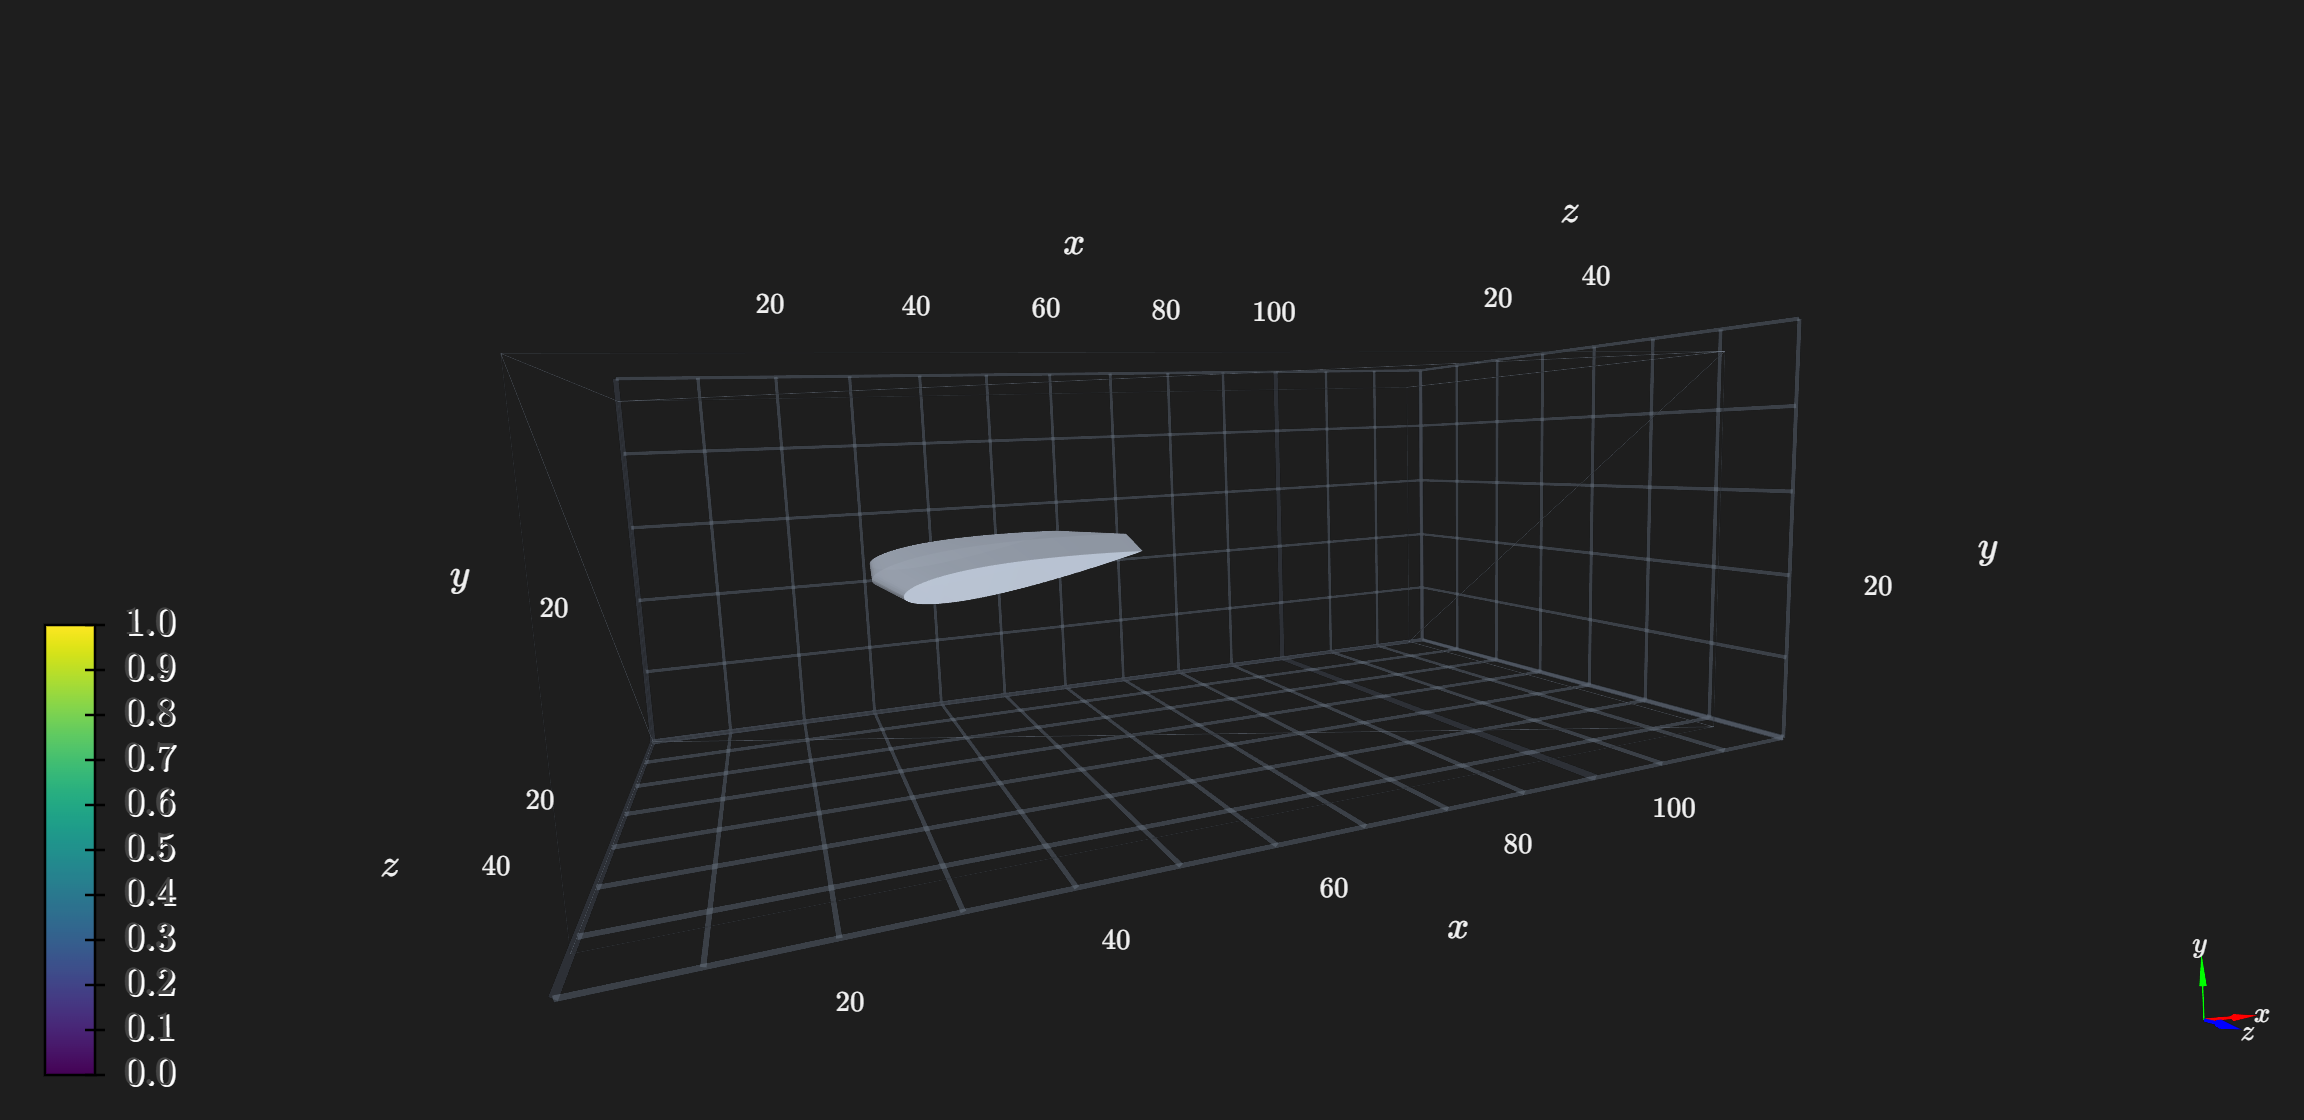

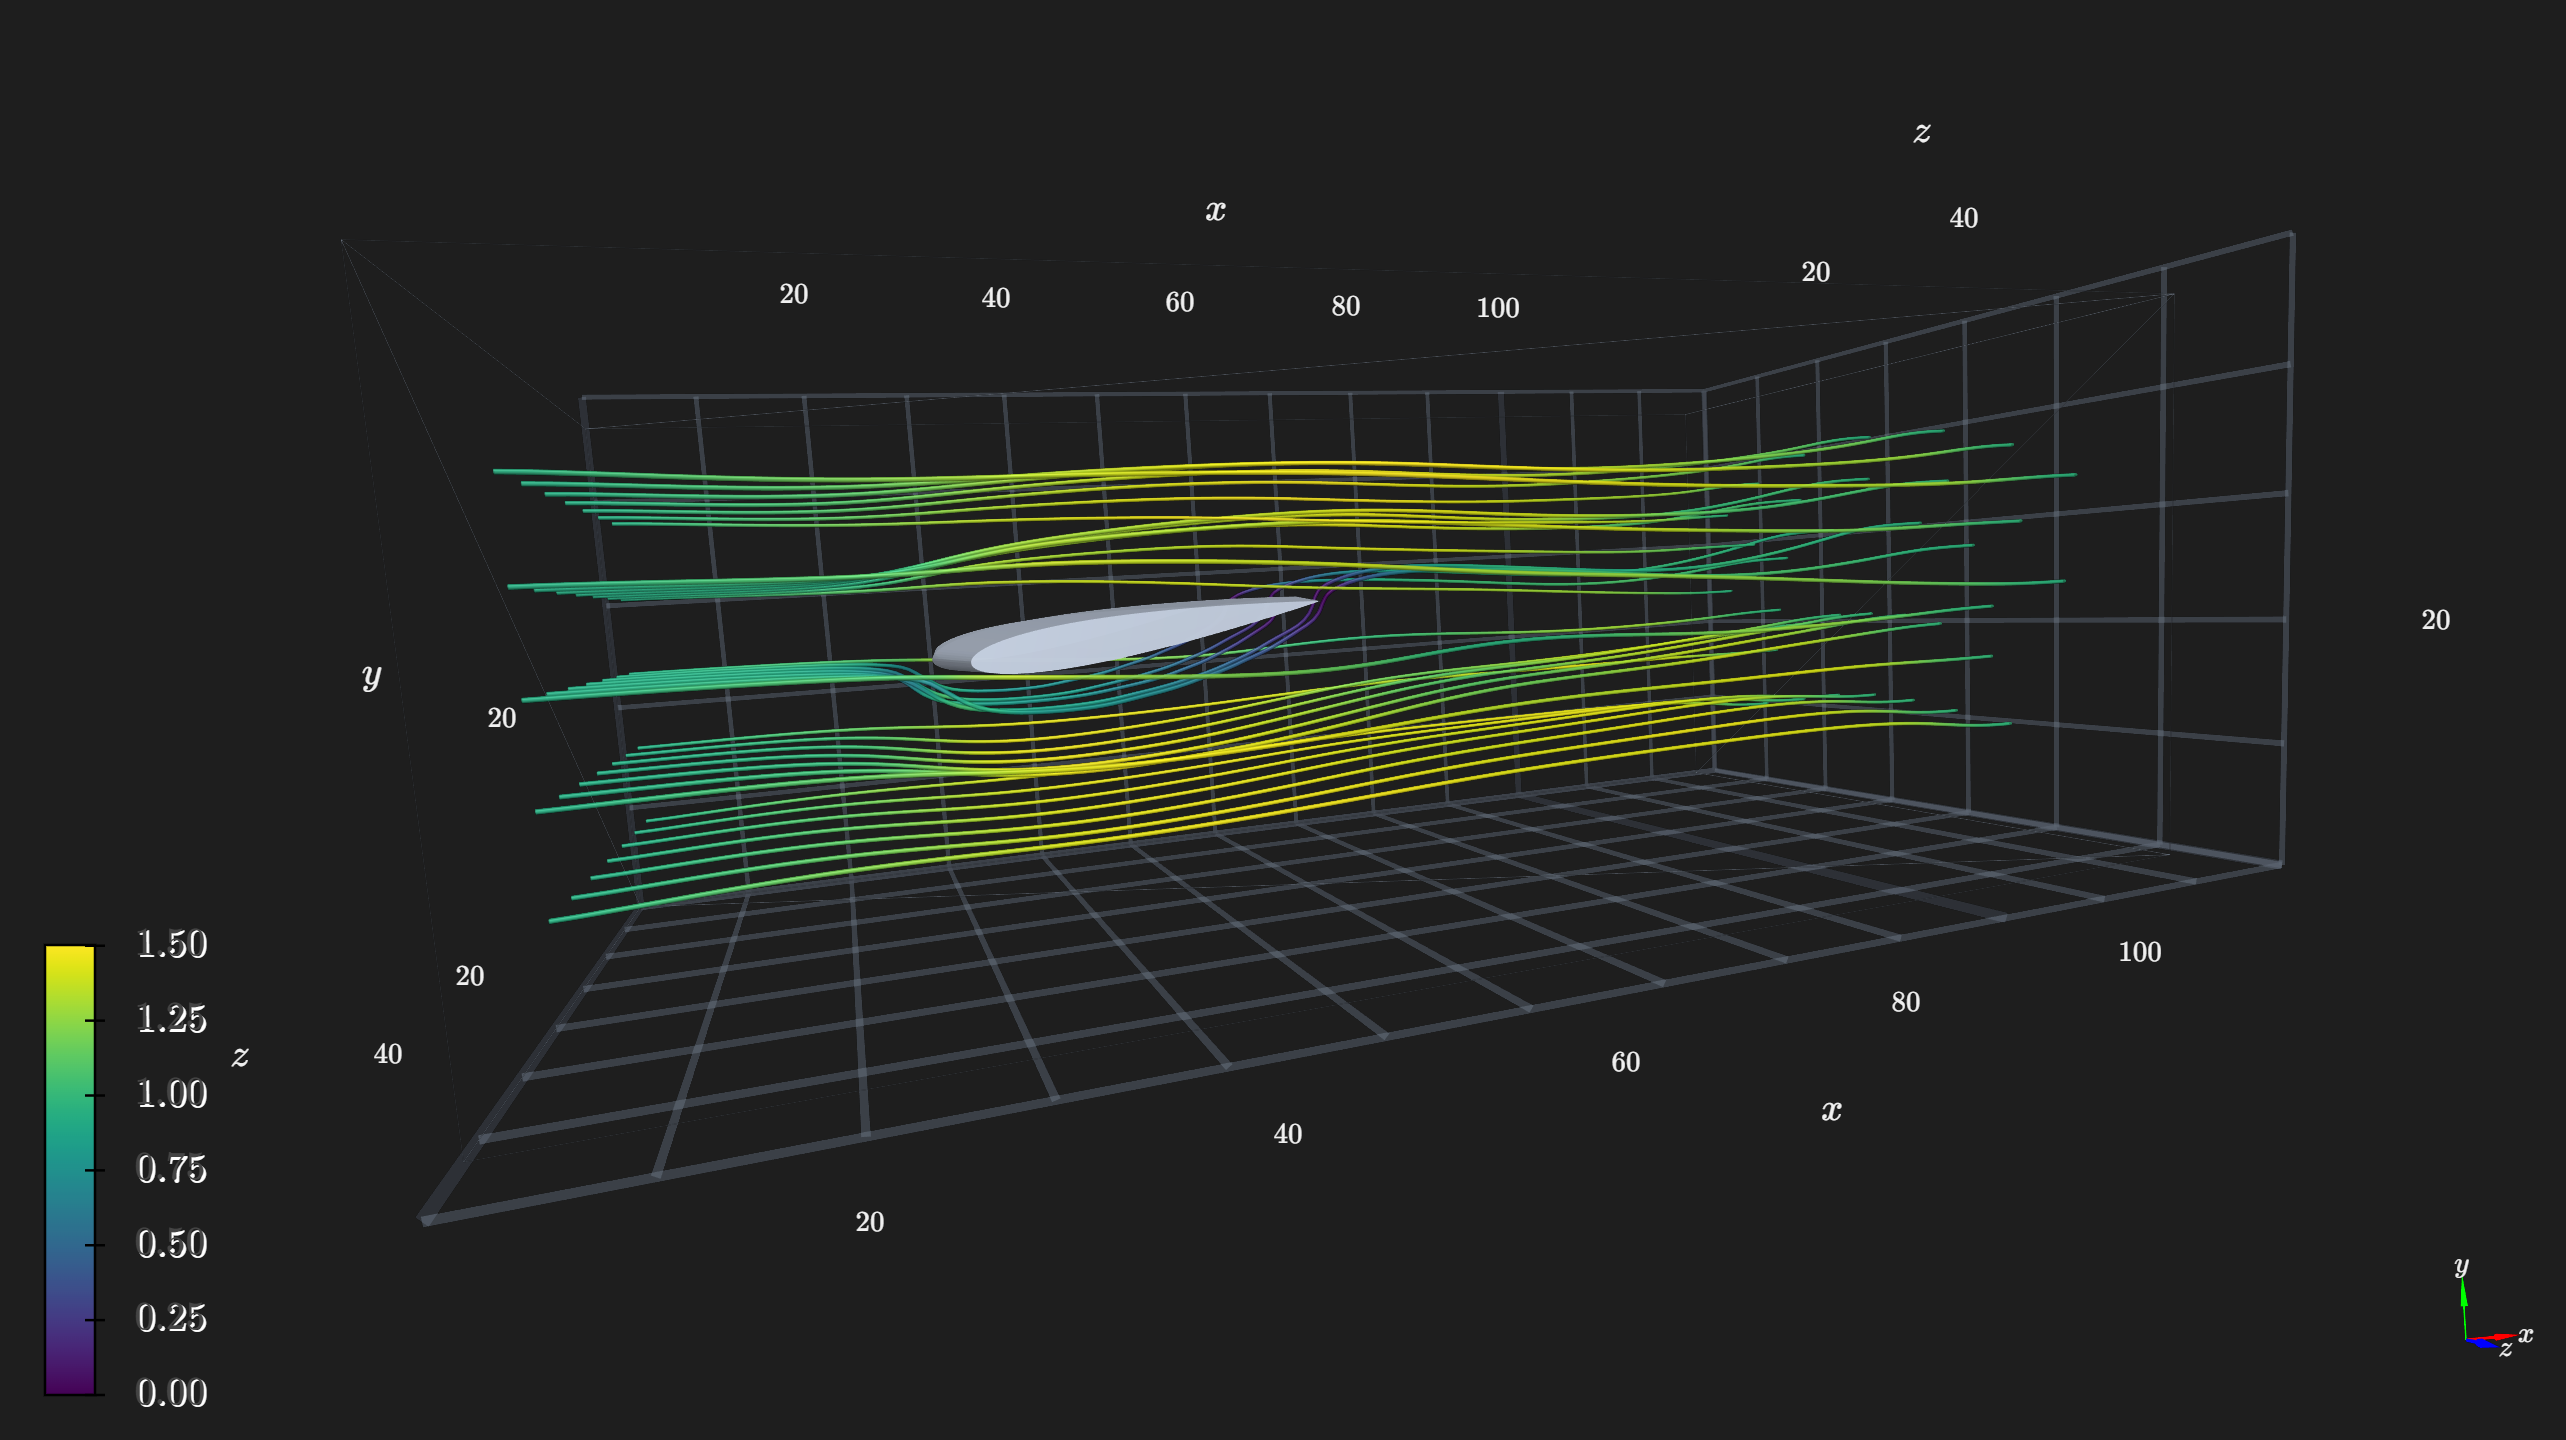